In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
# 1. Load the latent vectors from your trained model
experiment_dir = 'examples/OAI-ZIB/minimal_eikonal'
checkpoint = 'latest'

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f'Loaded latent vectors with shape: {X.shape}')


Loaded latent vectors with shape: (191, 256)


In [3]:
# 2. Inspect labels.pt
import torch
import numpy as np

labels_path = "/home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/labels.pt"
labels = torch.load(labels_path)

print(f"Loaded labels: {len(labels)}")
print("Sample labels:")
for i, (k, v) in enumerate(labels.items()):
    if i >= 50:
        break
    if isinstance(v, torch.Tensor):
        v = v.cpu().numpy()
    print(f"{k}: {v}")

# quick sanity stats
vals = []
for v in labels.values():
    if isinstance(v, torch.Tensor):
        v = v.cpu().numpy()
    vals.append(np.asarray(v, dtype=np.float32))

vals = np.stack(vals, axis=0)
print("Label array shape:", vals.shape)
print("Column means:", vals.mean(axis=0))
print("Column mins:", vals.min(axis=0))
print("Column maxs:", vals.max(axis=0))


Loaded labels: 191
Sample labels:
9256759: [ 1.  4.  1. 58.]
9263504: [ 1.  4.  1. 49.]
9284505: [ 1.  4.  1. 74.]
9287216: [ 1.  4.  1. 69.]
9326657: [ 1.  4.  1. 78.]
9340139: [ 1.  4.  1. 52.]
9365968: [ 1.  4.  1. 66.]
9393987: [ 1.  4.  1. 62.]
9413071: [ 1.  4.  1. 45.]
9422381: [ 1.  4.  1. 61.]
9439428: [ 1.  4.  1. 55.]
9457359: [ 1.  4.  1. 63.]
9475286: [ 1.  4.  1. 56.]
9604541: [ 1.  4.  1. 70.]
9638953: [ 1.  4.  1. 70.]
9680800: [ 1.  4.  1. 72.]
9689922: [ 1.  4.  1. 62.]
9710479: [ 1.  4.  1. 70.]
9858216: [ 1.  4.  1. 77.]
9933836: [ 1.  4.  1. 70.]
9012867: [ 1.  4.  0. 71.]
9031426: [ 1.  4.  0. 66.]
9036287: [ 1.  4.  0. 56.]
9070207: [ 1.  4.  1. 55.]
9101066: [ 1.  4.  1. 62.]
9114036: [ 1.  4.  0. 77.]
9145695: [ 1.  4.  0. 54.]
9148828: [ 1.  4.  0. 71.]
9156694: [ 1.  4.  0. 52.]
9158391: [ 1.  4.  0. 70.]
9173792: [ 1.  4.  0. 73.]
9204055: [ 1.  4.  1. 61.]
9208400: [ 1.  4.  0. 66.]
9218935: [ 1.  4.  0. 66.]
9250129: [ 1.  4.  0. 53.]
9277154: [ 1.  4.  0.

In [6]:
# 2. Load the filenames of the meshes and labels (diagnosis, kl_grade, sex, age)
import os
import json
import torch
import math

with open(os.path.join(experiment_dir, "specs.json"), "r") as f:
    specs = json.load(f)

mesh_root = specs.get("DataSourceMesh", specs["DataSource"])
train_split_file = specs.get("TrainSplit")
test_split_file = specs.get("TestSplit")
labels_path = os.path.join(mesh_root, "labels.pt")

def load_split(path):
    if not path:
        return []
    with open(path, "r") as f:
        return json.load(f)

def normalize_id_str(s):
    s = str(s).strip()
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except ValueError:
        pass
    return s

def normalize_mesh_id(filename):
    base = os.path.splitext(os.path.basename(filename))[0]
    if base.endswith("_femur"):
        base = base[:-6]
    return normalize_id_str(base)

train_split = load_split(train_split_file)
test_split = load_split(test_split_file)

# Combine train + test (unique), but fall back if sizes mismatch latent vectors
split_list = []
seen = set()
for name in train_split + test_split:
    if name not in seen:
        split_list.append(name)
        seen.add(name)

valid_filenames = split_list
if X.shape[0] != len(valid_filenames):
    if len(train_split) == X.shape[0]:
        print("Latent count matches train split; using train split only.")
        valid_filenames = train_split
    else:
        print("Warning: latent count does not match split sizes.")

print(f"Train split: {len(train_split)}")
print(f"Test split: {len(test_split)}")
print(f"Using {len(valid_filenames)} filenames for label matching")

mesh_params = []
if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path, map_location="cpu")

    label_map = {}
    if isinstance(all_labels, dict):
        for k, v in all_labels.items():
            label_map[normalize_id_str(k)] = v
    elif hasattr(all_labels, "__len__") and len(all_labels) == len(valid_filenames):
        for idx, filename in enumerate(valid_filenames):
            key = normalize_mesh_id(filename)
            label_map[key] = all_labels[idx]
    else:
        print("Warning: labels are not a dict and length does not match filenames; skipping label lookup.")

    missing = 0
    for filename in valid_filenames:
        mesh_id = normalize_mesh_id(filename)
        params = {
            "diagnosis": -1,
            "kl_grade": float("nan"),
            "sex": -1,
            "age": float("nan"),
        }
        if mesh_id in label_map:
            label = label_map[mesh_id]
            if isinstance(label, torch.Tensor):
                label = label.cpu().numpy()
            diagnosis = float(label[0])
            kl_grade = float(label[1])
            sex = float(label[2])
            age = float(label[3])

            params["diagnosis"] = int(diagnosis) if not math.isnan(diagnosis) else -1
            params["kl_grade"] = kl_grade
            params["sex"] = int(sex) if not math.isnan(sex) else -1
            params["age"] = age
        else:
            missing += 1
            # print(f"Warning: No label found for {mesh_id}")
        mesh_params.append(params)

    if missing:
        print(f"Warning: {missing} filenames had no labels.")
else:
    print(f"labels.pt not found at {labels_path}")


Train split: 191
Test split: 19
Using 191 filenames for label matching
Loading labels from /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/labels.pt


In [7]:
# Extract parameters for visualization (diagnosis, kl_grade, sex, age)
diagnosis = np.array([p.get('diagnosis', -1) for p in mesh_params])
kl_grade = np.array([p.get('kl_grade', float('nan')) for p in mesh_params], dtype=float)
sex = np.array([p.get('sex', -1) for p in mesh_params])
age = np.array([p.get('age', float('nan')) for p in mesh_params], dtype=float)

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((diagnosis, kl_grade, sex, age))
factor_names = ['diagnosis', 'kl_grade', 'sex', 'age']


In [8]:
# AD prediction imports (independent cell)
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


In [9]:
# Predict AD (diagnosis == 1) from 256D latent vectors using a small MLP
mask = diagnosis >= 0
X_valid = X[mask]
y = (diagnosis[mask] == 1).astype(np.int64)

if X_valid.shape[1] != 256:
    print(f'Warning: expected 256D latent, got {X_valid.shape[1]}D')

if len(np.unique(y)) < 2:
    raise ValueError('Need at least two classes for AD prediction. Check labels.')

X_train, X_val, y_train, y_val = train_test_split(
    X_valid, y, test_size=0.2, random_state=32, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val).float(),
    torch.from_numpy(y_val)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2),
).to(device)

class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (2.0 * class_counts), dtype=torch.float32, device=device
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(200):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

model.eval()
with torch.no_grad():
    val_logits = []
    val_targets = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        val_logits.append(logits.cpu())
        val_targets.append(yb)

val_logits = torch.cat(val_logits, dim=0)
val_targets = torch.cat(val_targets, dim=0).numpy()
val_probs = torch.softmax(val_logits, dim=1)[:, 1].numpy()
val_preds = (val_probs >= 0.5).astype(np.int64)

acc = accuracy_score(val_targets, val_preds)
auc = roc_auc_score(val_targets, val_probs)
print(f'Validation accuracy: {acc:.3f}  AUROC: {auc:.3f}')
print(classification_report(val_targets, val_preds, digits=3))


Validation accuracy: 0.949  AUROC: 0.963
              precision    recall  f1-score   support

           0      0.963     0.963     0.963        27
           1      0.917     0.917     0.917        12

    accuracy                          0.949        39
   macro avg      0.940     0.940     0.940        39
weighted avg      0.949     0.949     0.949        39



In [10]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [11]:
# 3.1. PCA
print('Applying PCA...')
pca = PCA(n_components=4)
Y_pca = pca.fit_transform(X)
results['PCA'] = Y_pca
transformed_latents['PCA'] = Y_pca
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

# check if kl_grade or age is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))

for name, arr in [('kl_grade', kl_grade), ('age', age)]:
    mask = np.isfinite(arr)
    if np.any(mask):
        corr = np.corrcoef(distances[mask], arr[mask])[0, 1]
        print(f'Correlation between distance from origin and {name}: {corr:.4f}')
    else:
        print(f'No finite {name} values to compute distance correlation.')

distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA
best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions
for n_neighbors in range(100, 120, 10):
    for n_components in [4]:
        try:
            hlle = LocallyLinearEmbedding(
                n_neighbors=n_neighbors,
                n_components=n_components,
                method='hessian',
                eigen_solver='dense'
            )
            Z = hlle.fit_transform(X)

            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            correlations = []
            mask = diagnosis >= 0
            for comp in range(n_components):
                if np.any(mask):
                    corr = np.corrcoef(Y_hlle_ica[mask, comp], diagnosis[mask])[0, 1]
                else:
                    corr = float('nan')
                correlations.append(corr)
            print(correlations)

            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]

            print(f'n_neighbors: {n_neighbors}, n_components: {n_components}, '
                  f'best component correlation: {best_component_corr:.4f}')

            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)

        except Exception as e:
            print(f'Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}')

if best_Y_hlle_ica is not None:
    print('\nBest parameter set:')
    print(f'n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}')
    results['HLLE+ICA'] = best_Y_hlle_ica
    transformed_latents['HLLE+ICA'] = best_Y_hlle_ica
else:
    print('No valid HLLE+ICA transformation found.')


Applying PCA...
PCA explained variance ratio: 0.1959
Correlation between distance from origin and kl_grade: 0.1002
Correlation between distance from origin and age: -0.1524


[0.10587126842386195, 0.15036410663470795, -0.023196458635510973, 0.45148574796752955]
n_neighbors: 100, n_components: 4, best component correlation: 0.4515
[0.15002500007743227, -0.10430706955263372, 0.4455704368377658, -0.027495364036090104]
n_neighbors: 110, n_components: 4, best component correlation: 0.4456

Best parameter set:
n_neighbors: 100, n_components: 4, best component: 3 best correlation: 0.4515


In [12]:
# 3.3. NMF
print('Applying NMF...')
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

label_mask = np.isin(diagnosis, [0, 1])

for n_components in [4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        W = nmf.fit_transform(X_offset)

        correlations = []
        for comp in range(n_components):
            if np.any(label_mask):
                corr = np.corrcoef(W[label_mask, comp], diagnosis[label_mask])[0, 1]
            else:
                corr = float('nan')
            correlations.append(corr)

        best_component_corr = max(correlations, key=abs)
        print(f'n_components: {n_components}, best component correlation (diagnosis): {best_component_corr:.4f}')

        if best_corr_nmf is None or abs(best_component_corr) > abs(best_corr_nmf):
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components

    except Exception as e:
        print(f'NMF failed for n_components: {n_components} due to: {e}')

if best_W_nmf is not None:
    results['NMF'] = best_W_nmf
    transformed_latents['NMF'] = best_W_nmf


Applying NMF...
n_components: 4, best component correlation (diagnosis): 0.4476


In [13]:
# 3.4. Factor Analysis
print('Applying Factor Analysis...')
fa = FactorAnalysis(n_components=4, random_state=42)
Y_fa = fa.fit_transform(X)
results['FA'] = Y_fa
transformed_latents['FA'] = Y_fa

center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))

for name, arr in [('kl_grade', kl_grade), ('age', age)]:
    mask = np.isfinite(arr)
    if np.any(mask):
        corr = np.corrcoef(distances[mask], arr[mask])[0, 1]
        print(f'Correlation between distance from origin and {name}: {corr:.4f}')
    else:
        print(f'No finite {name} values to compute distance correlation.')

distances_Y_fa = distances
distances_all.append(distances)


Applying Factor Analysis...
Correlation between distance from origin and kl_grade: 0.1291
Correlation between distance from origin and age: -0.2083


In [14]:
# 3.5. ICA
print('Applying ICA...')
ica = FastICA(n_components=4, random_state=42)
Y_ica = ica.fit_transform(X)
results['ICA'] = Y_ica
transformed_latents['ICA'] = Y_ica

center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))

for name, arr in [('kl_grade', kl_grade), ('age', age)]:
    mask = np.isfinite(arr)
    if np.any(mask):
        corr = np.corrcoef(distances[mask], arr[mask])[0, 1]
        print(f'Correlation between distance from origin and {name}: {corr:.4f}')
    else:
        print(f'No finite {name} values to compute distance correlation.')

distances_Y_ica = distances
distances_all.append(distances)


Applying ICA...
Correlation between distance from origin and kl_grade: 0.1423
Correlation between distance from origin and age: -0.2062


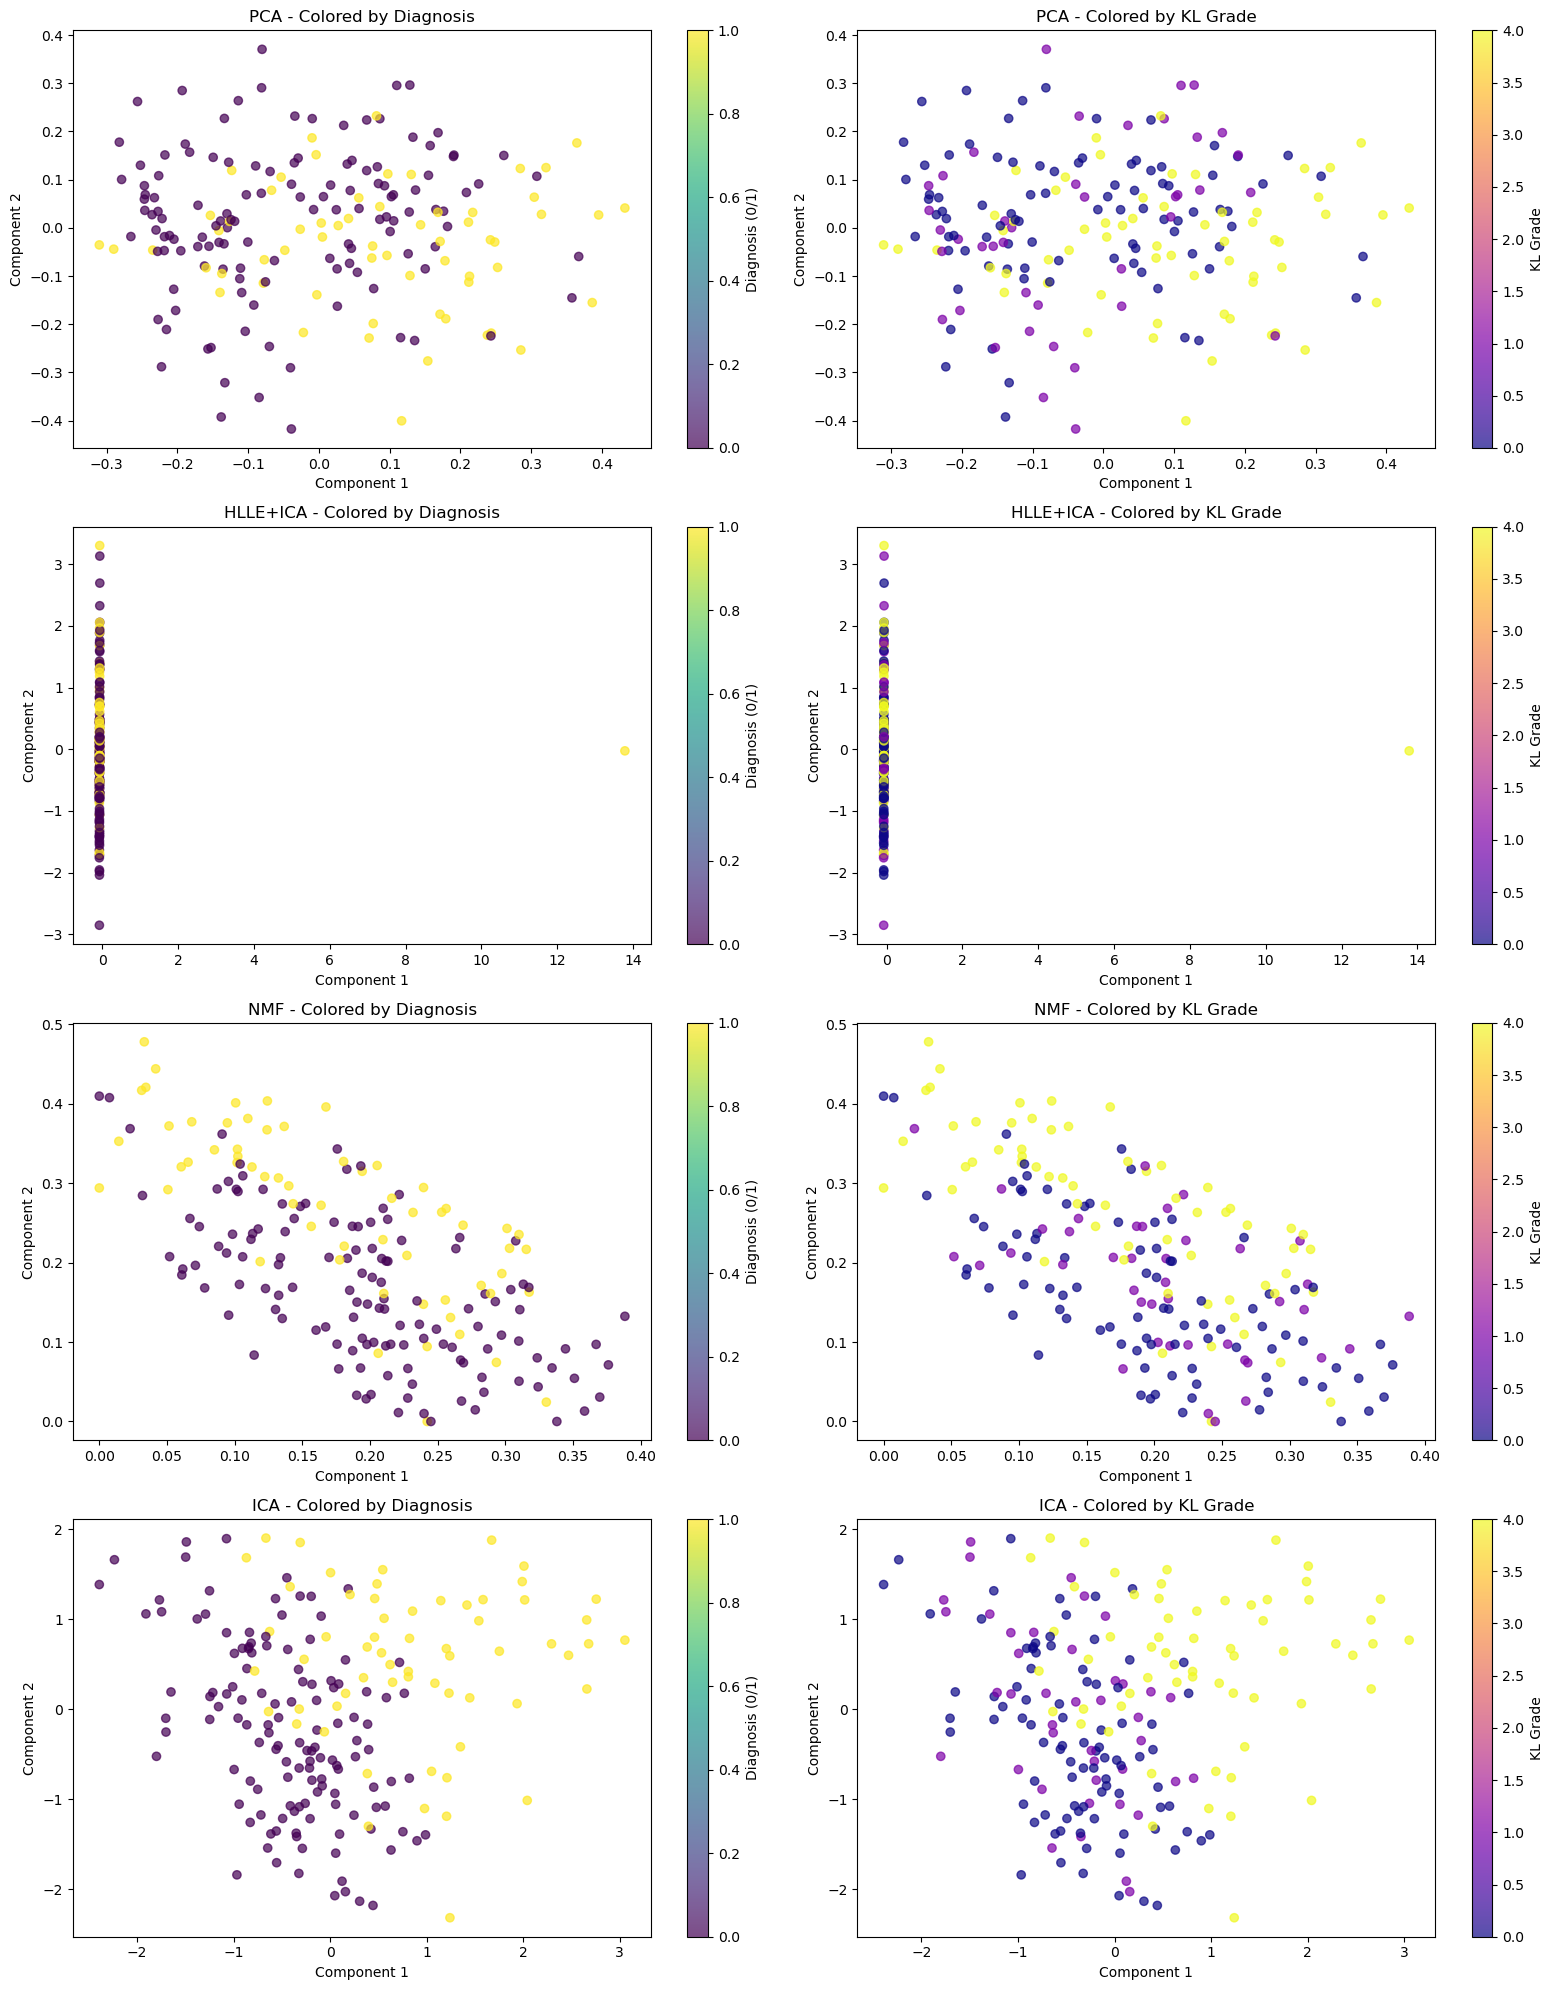

In [15]:
# 4. Visualize results
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

techniques = ['PCA', 'HLLE+ICA', 'NMF', 'ICA']
for i, technique in enumerate(techniques):
    if np.all(results[technique] == 0):
        continue

    # Diagnosis
    scatter = axes[i, 0].scatter(
        results[technique][:, 0], results[technique][:, 1],
        c=diagnosis, cmap='viridis', alpha=0.7
    )
    axes[i, 0].set_title(f'{technique} - Colored by Diagnosis')
    axes[i, 0].set_xlabel('Component 1')
    axes[i, 0].set_ylabel('Component 2')
    plt.colorbar(scatter, ax=axes[i, 0], label='Diagnosis (0/1)')

    # KL grade
    mask = np.isfinite(kl_grade)
    scatter = axes[i, 1].scatter(
        results[technique][mask, 0], results[technique][mask, 1],
        c=kl_grade[mask], cmap='plasma', alpha=0.7
    )
    axes[i, 1].set_title(f'{technique} - Colored by KL Grade')
    axes[i, 1].set_xlabel('Component 1')
    axes[i, 1].set_ylabel('Component 2')
    plt.colorbar(scatter, ax=axes[i, 1], label='KL Grade')

plt.tight_layout()
plt.show()


In [16]:
# 5. Correlation Analysis (diagnosis only)
print('\nCorrelation Analysis (Diagnosis):')
for technique in techniques:
    if np.all(results[technique] == 0):
        continue

    print(f'\n{technique} Analysis:')
    num_components = results[technique].shape[1]
    if np.any(diagnosis >= 0):
        mask = diagnosis >= 0
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], diagnosis[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with diagnosis: {corr:.4f}')
    else:
        print('No valid diagnosis labels available.')



Correlation Analysis (Diagnosis):

PCA Analysis:
Component 1 correlation with diagnosis: 0.3485
Component 2 correlation with diagnosis: -0.1646
Component 3 correlation with diagnosis: -0.3445
Component 4 correlation with diagnosis: -0.5142

HLLE+ICA Analysis:
Component 1 correlation with diagnosis: 0.1059
Component 2 correlation with diagnosis: 0.1504
Component 3 correlation with diagnosis: -0.0232
Component 4 correlation with diagnosis: 0.4515

NMF Analysis:
Component 1 correlation with diagnosis: -0.1279
Component 2 correlation with diagnosis: 0.4476
Component 3 correlation with diagnosis: -0.1785
Component 4 correlation with diagnosis: -0.2820

ICA Analysis:
Component 1 correlation with diagnosis: 0.6183
Component 2 correlation with diagnosis: 0.3622
Component 3 correlation with diagnosis: -0.0342
Component 4 correlation with diagnosis: -0.1301


In [17]:
# 6. SAP Analysis (Diagnosis only)
from sdf_utils import sap as sap_metric

print('SAP Analysis (Diagnosis only):')

def _mask_codes_factors(codes, factors, mask=None):
    codes = np.asarray(codes)
    factors = np.asarray(factors)
    if factors.ndim == 1:
        factors = factors.reshape(-1, 1)
    if codes.shape[0] != factors.shape[0]:
        print(f'  Skipping: codes/factors row mismatch ({codes.shape[0]} vs {factors.shape[0]})')
        return None, None
    if mask is not None:
        codes = codes[mask]
        factors = factors[mask]
    finite_mask = np.isfinite(factors).all(axis=1) & np.isfinite(codes).all(axis=1)
    codes = codes[finite_mask]
    factors = factors[finite_mask]
    if codes.shape[0] < 4:
        print('  Skipping: not enough valid samples after filtering.')
        return None, None
    return codes, factors


def _sap_disease(codes, diagnosis, nb_bins=10, train_frac=0.8, seed=0, pred_sample_n=5):
    mask = diagnosis >= 0
    codes_m, factors_m = _mask_codes_factors(codes, diagnosis, mask=mask)
    if codes_m is None:
        return

    sap_score = sap_metric.sap(
        factors_m,
        codes_m,
        continuous_factors=False,
        nb_bins=nb_bins,
        regression=False,
    )
    sap_matrix = sap_metric.sap_score_matrix(
        factors_m,
        codes_m,
        continuous_factors=False,
        nb_bins=nb_bins,
        regression=False,
    )
    per_latent = sap_matrix[0] if sap_matrix.shape[0] else np.array([])

    loc_sap, loc_err, loc_pred = sap_metric.sap_binary_classification_locatello(
        factors_m,
        codes_m,
        train_frac=train_frac,
        C=0.01,
        random_state=seed,
        return_predictions=True,
        pred_sample_n=pred_sample_n,
    )

    hold_train_acc, hold_test_acc, hold_pred = sap_metric.sap_classification_holdout_predictions(
        factors_m,
        codes_m,
        continuous_factors=False,
        nb_bins=nb_bins,
        train_frac=train_frac,
        random_state=seed,
        pred_sample_n=pred_sample_n,
    )

    pred_info = sap_metric.sap_classification_predictions(
        factors_m,
        codes_m,
        continuous_factors=False,
        nb_bins=nb_bins,
        pred_sample_n=pred_sample_n,
    )

    holdout_gap = float('nan')
    if hold_test_acc is not None and hold_test_acc.size:
        vals = hold_test_acc[0]
        vals = vals[np.isfinite(vals)]
        if vals.size >= 2:
            vals_sorted = np.sort(vals)
            holdout_gap = float(vals_sorted[-1] - vals_sorted[-2])

    print(f'  Disease SAP: {sap_score:.6f} | Locatello SAP: {loc_sap:.6f} | Kumar holdout gap: {holdout_gap:.6f}')
    print('  Per-latent (disease):')
    for dim in range(codes_m.shape[1]):
        sap_acc = float(per_latent[dim]) if dim < per_latent.size else float('nan')
        hold_acc = (
            float(hold_test_acc[0, dim])
            if hold_test_acc is not None and hold_test_acc.shape[1] > dim
            else float('nan')
        )
        loc_acc = (
            float(1.0 - loc_err[0, dim])
            if loc_err is not None and loc_err.shape[1] > dim and np.isfinite(loc_err[0, dim])
            else float('nan')
        )
        info = pred_info[0][dim] if pred_info else None
        counts = info.get('pred_counts') if info else None
        print(f'    dim {dim:2d} | sap_acc={sap_acc:.4f} | hold_acc={hold_acc:.4f} | loc_acc={loc_acc:.4f} | pred_counts={counts}')


for technique in techniques:
    if np.all(results[technique] == 0):
        continue
    print(f'{technique} SAP:')
    codes = results[technique]
    _sap_disease(codes, diagnosis)


SAP Analysis (Diagnosis only):
PCA SAP:
  Disease SAP: 0.062827 | Locatello SAP: 0.131579 | Kumar holdout gap: 0.078947
  Per-latent (disease):
    dim  0 | sap_acc=0.7435 | hold_acc=0.7105 | loc_acc=0.7105 | pred_counts={0.0: 167, 1.0: 24}
    dim  1 | sap_acc=0.6806 | hold_acc=0.6842 | loc_acc=0.6842 | pred_counts={0.0: 191}
    dim  2 | sap_acc=0.7225 | hold_acc=0.6842 | loc_acc=0.6316 | pred_counts={0.0: 177, 1.0: 14}
    dim  3 | sap_acc=0.8063 | hold_acc=0.7895 | loc_acc=0.8421 | pred_counts={0.0: 163, 1.0: 28}
HLLE+ICA SAP:
  Disease SAP: 0.094241 | Locatello SAP: 0.026316 | Kumar holdout gap: 0.026316
  Per-latent (disease):
    dim  0 | sap_acc=0.7173 | hold_acc=0.5000 | loc_acc=0.6842 | pred_counts={0.0: 180, 1.0: 11}
    dim  1 | sap_acc=0.6806 | hold_acc=0.6842 | loc_acc=0.6842 | pred_counts={0.0: 191}
    dim  2 | sap_acc=0.6963 | hold_acc=0.6579 | loc_acc=0.6842 | pred_counts={0.0: 188, 1.0: 3}
    dim  3 | sap_acc=0.8115 | hold_acc=0.7105 | loc_acc=0.7105 | pred_counts={

In [18]:
# 7. Reconstruction Error (PCA / ICA)
print('Reconstruction Error:')

if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')


def _mse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        print(f'  Shape mismatch: {a.shape} vs {b.shape}')
        return float('nan')
    mask = np.isfinite(a) & np.isfinite(b)
    if not np.any(mask):
        return float('nan')
    return float(np.mean((a[mask] - b[mask]) ** 2))

# PCA reconstruction
if 'pca' in globals() and 'results' in globals() and results.get('PCA') is not None:
    try:
        X_pca_rec = pca.inverse_transform(results['PCA'])
        mse_pca = _mse(X, X_pca_rec)
        print(f'  PCA reconstruction MSE: {mse_pca:.6f}')
    except Exception as e:
        print(f'  PCA reconstruction failed: {e}')
else:
    print('  PCA reconstruction skipped (missing pca/results).')

# ICA reconstruction
if 'ica' in globals() and 'results' in globals() and results.get('ICA') is not None:
    try:
        X_ica_rec = ica.inverse_transform(results['ICA'])
        mse_ica = _mse(X, X_ica_rec)
        print(f'  ICA reconstruction MSE: {mse_ica:.6f}')
    except Exception as e:
        print(f'  ICA reconstruction failed: {e}')
else:
    print('  ICA reconstruction skipped (missing ica/results).')

Reconstruction Error:
  PCA reconstruction MSE: 0.001083
  ICA reconstruction MSE: 0.001083


In [19]:
# 8. Reconstruct shapes + average Chamfer distance (PCA/ICA recon latents)
from deep_sdf import mesh as ds_mesh
from deep_sdf import metrics as ds_metrics

print('\nReconstructing shapes and computing average Chamfer distance...')

if 'experiment_dir' not in globals():
    raise RuntimeError('experiment_dir not found. Run the latent loading cell first.')
if 'checkpoint' not in globals():
    checkpoint = 'latest'
if 'latent_vectors' not in globals():
    raise RuntimeError('latent_vectors not found. Run the latent loading cell first.')
if 'valid_filenames' not in globals():
    raise RuntimeError('valid_filenames not found. Run the split/label loading cell first.')
if 'mesh_root' not in globals():
    raise RuntimeError('mesh_root not found. Run the split/label loading cell first.')
if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')

# Config (reduced for GPU memory)
num_shapes = 10
grid_res = 64
max_batch = 2 ** 16
num_mesh_samples = 10000
use_cpu = False  # set True to force CPU if GPU is busy

# Choose latent source: 'ORIG', 'PCA', or 'ICA'
latent_source = 'PCA'

latent_source = latent_source.upper()
if latent_source not in ('ORIG', 'PCA', 'ICA'):
    raise ValueError(f'Unknown latent_source: {latent_source}')

# Device
import torch

device = torch.device('cpu')
if torch.cuda.is_available() and not use_cpu:
    device = torch.device('cuda')

# Load decoder (handle DataParallel vs non-DataParallel checkpoints)
specs = ws.load_experiment_specifications(experiment_dir)
ckpt_path = os.path.join(experiment_dir, ws.model_params_subdir, checkpoint + '.pth')
if not os.path.isfile(ckpt_path):
    raise RuntimeError(f'Checkpoint not found: {ckpt_path}')
ckpt = torch.load(ckpt_path, map_location='cpu')
state_dict = ckpt.get('model_state_dict', ckpt)
# Strip DataParallel prefix if present
if all(k.startswith('module.') for k in state_dict.keys()):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

decoder = ws.build_decoder(experiment_dir, specs)
missing, unexpected = decoder.load_state_dict(state_dict, strict=False)
if missing or unexpected:
    print(f'  load_state_dict missing={len(missing)} unexpected={len(unexpected)}')
decoder = decoder.to(device)
decoder.eval()

# Build reconstructed latents (if requested)
recon_latents = None
if latent_source == 'PCA':
    if 'pca' not in globals() or 'results' not in globals() or results.get('PCA') is None:
        raise RuntimeError('PCA results not found. Run the PCA cell first.')
    recon_latents = pca.inverse_transform(results['PCA'])
elif latent_source == 'ICA':
    if 'ica' not in globals() or 'results' not in globals() or results.get('ICA') is None:
        raise RuntimeError('ICA results not found. Run the ICA cell first.')
    recon_latents = ica.inverse_transform(results['ICA'])

# Determine usable count (align to labels if available)
n_total = min(len(valid_filenames), X.shape[0])
if 'diagnosis' in globals():
    n_total = min(n_total, len(diagnosis))

if n_total == 0:
    raise RuntimeError('No samples available to reconstruct.')

# Use only samples with diagnosis labels if available
all_indices = np.arange(n_total)
if 'diagnosis' in globals():
    label_mask = diagnosis[:n_total] >= 0
    if np.any(label_mask):
        all_indices = all_indices[label_mask]

if all_indices.size == 0:
    raise RuntimeError('No labeled samples available to reconstruct.')

num_shapes = min(num_shapes, len(all_indices))
indices = all_indices[:num_shapes]

# Helper to fetch latent
def _get_latent(idx):
    if recon_latents is not None:
        z = torch.tensor(recon_latents[idx:idx+1], dtype=torch.float32)
    elif torch.is_tensor(latent_vectors):
        z = latent_vectors[idx:idx+1]
    elif isinstance(latent_vectors, list):
        z = latent_vectors[idx]
        if torch.is_tensor(z) and z.dim() == 1:
            z = z.unsqueeze(0)
    else:
        z = torch.tensor(X[idx:idx+1], dtype=torch.float32)
    return z.to(device)

# Helper to resolve GT mesh path (handles _femur suffix)
def _resolve_mesh_path(base_name):
    candidates = [base_name]
    if not base_name.endswith('_femur'):
        candidates.append(base_name + '_femur')

    for b in candidates:
        for ext in ('.obj', '.ply'):
            c = os.path.join(mesh_root, b + ext)
            if os.path.isfile(c):
                return c

    # fallback: any file with matching base
    for b in candidates:
        matches = [p for p in os.listdir(mesh_root) if os.path.splitext(p)[0] == b]
        if matches:
            return os.path.join(mesh_root, matches[0])
    return None

chamfers = []
missing = 0
failed = 0

for idx in indices:
    filename = valid_filenames[idx]
    base_name = os.path.splitext(os.path.basename(filename))[0]
    gt_path = _resolve_mesh_path(base_name)
    if gt_path is None:
        missing += 1
        continue

    try:
        z = _get_latent(idx)
        with torch.no_grad():
            gen_mesh = ds_mesh.create_mesh(
                decoder,
                z,
                N=grid_res,
                max_batch=max_batch,
                return_trimesh=True,
            )
        if gen_mesh is None:
            failed += 1
            continue
        cd, _ = ds_metrics.compute_metric(
            gt_mesh=gt_path,
            gen_mesh=gen_mesh,
            num_mesh_samples=num_mesh_samples,
            metric='chamfer',
        )
        chamfers.append(cd)
        del gen_mesh
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    except Exception as e:
        print(f'  Failed at idx {idx} ({base_name}): {e}')
        failed += 1
        if device.type == 'cuda':
            torch.cuda.empty_cache()

if chamfers:
    mean_cd = float(np.mean(chamfers))
    print(f'Average Chamfer distance over {len(chamfers)} shapes: {mean_cd:.6f}')
else:
    print('No Chamfer distances computed.')

if missing or failed:
    print(f'Missing meshes: {missing} | Failed reconstructions: {failed}')



Reconstructing shapes and computing average Chamfer distance...
Average Chamfer distance over 10 shapes: 0.001697


In [20]:
# Add this cell to your notebook (diagnosis-only context)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use original latent vectors (X)
X_clustering = X.copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionaries to store results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)

    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)

    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")

    if k == 2:
        clustering_results['KMeans_2'] = cluster_labels
        cluster_metrics['KMeans_2'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels


=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.023, Calinski-Harabasz=5.7, Davies-Bouldin=5.728
K=3: Silhouette=0.018, Calinski-Harabasz=4.5, Davies-Bouldin=5.474
K=4: Silhouette=0.015, Calinski-Harabasz=3.7, Davies-Bouldin=4.423
K=5: Silhouette=0.005, Calinski-Harabasz=3.4, Davies-Bouldin=5.334
K=6: Silhouette=0.001, Calinski-Harabasz=3.0, Davies-Bouldin=5.069
K=7: Silhouette=0.008, Calinski-Harabasz=2.8, Davies-Bouldin=4.000
K=8: Silhouette=0.001, Calinski-Harabasz=2.6, Davies-Bouldin=4.521
K=9: Silhouette=-0.006, Calinski-Harabasz=2.4, Davies-Bouldin=4.946
K=10: Silhouette=-0.002, Calinski-Harabasz=2.3, Davies-Bouldin=4.184

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 7


In [21]:
# --- GMM K=2 + GMM Best (store in clustering_results, no saving) ---
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

if 'X' not in globals():
    raise RuntimeError("X not found. Run latent loading cell first.")

# build X_scaled if missing
if 'X_scaled' not in globals():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

if 'clustering_results' not in globals():
    clustering_results = {}

# GMM K=2
gmm_k2 = GaussianMixture(n_components=2, random_state=42)
gmm_k2_labels = gmm_k2.fit_predict(X_scaled)
clustering_results['GMM_2'] = gmm_k2_labels
print("Stored clustering_results['GMM_2']")

# GMM Best by silhouette
k_range = range(2, 11)
best_k = None
best_sil = -1
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    if sil > best_sil:
        best_sil = sil
        best_k = k

gmm_best = GaussianMixture(n_components=best_k, random_state=42)
gmm_best_labels = gmm_best.fit_predict(X_scaled)
clustering_results['GMM_Best'] = gmm_best_labels
print(f"Stored clustering_results['GMM_Best'] (K={best_k}, silhouette={best_sil:.3f})")


Stored clustering_results['GMM_2']
Stored clustering_results['GMM_Best'] (K=2, silhouette=0.034)



6. Visualization of Clustering Results:
UMAP failed (check_array() got an unexpected keyword argument 'ensure_all_finite'); using t-SNE for visualization


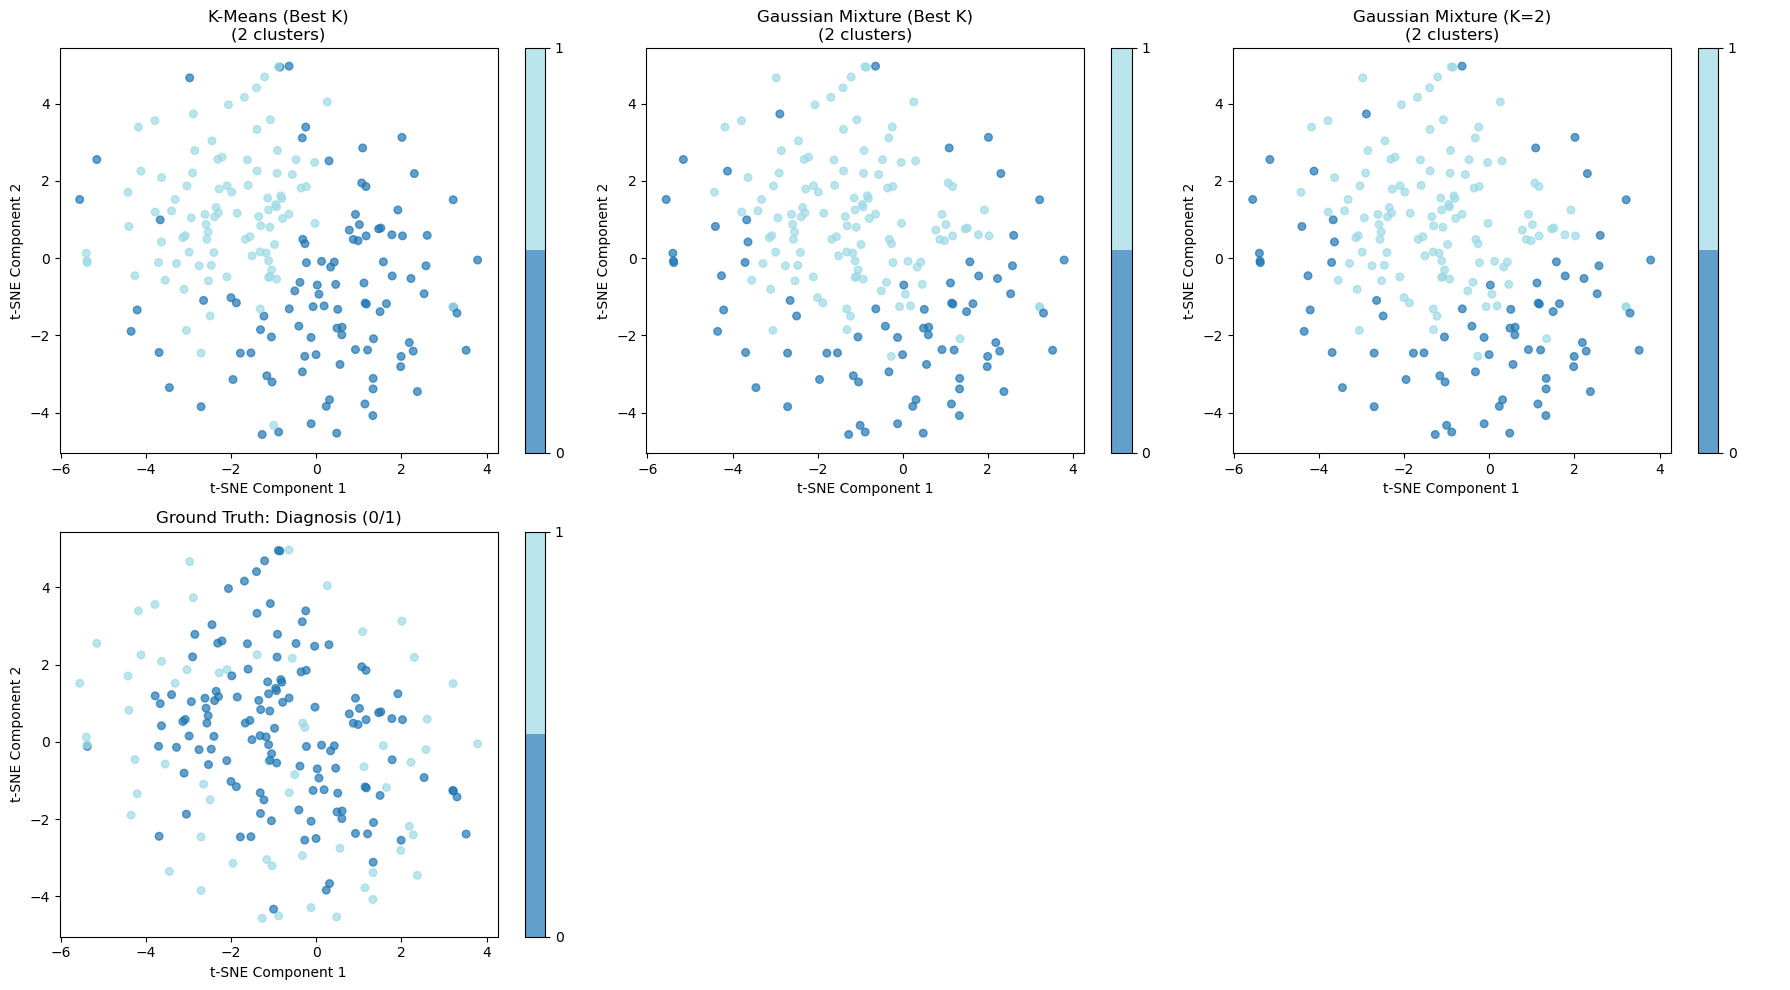

In [168]:
# 6. Visualize clustering results using dimensionality reduction
# (KMeans_Best, GMM_Best, GMM_2 + Diagnosis)
print('\n6. Visualization of Clustering Results:')

import numpy as np
import matplotlib.pyplot as plt
import math

embedding_label = 'UMAP'
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print('Using UMAP for visualization')
except Exception as e:
    from sklearn.manifold import TSNE
    embedding_label = 't-SNE'
    print(f'UMAP failed ({e}); using t-SNE for visualization')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_umap = tsne.fit_transform(X_scaled)

method_specs = [
    ('KMeans_Best', 'K-Means (Best K)'),
    ('GMM_Best', 'Gaussian Mixture (Best K)'),
    ('GMM_2', 'Gaussian Mixture (K=2)'),
]

methods_present = [(m, n) for m, n in method_specs if m in clustering_results]
has_diag = 'diagnosis' in globals() and len(diagnosis) == X_umap.shape[0]

n_panels = len(methods_present) + (1 if has_diag else 0)
if n_panels == 0:
    print('No clustering results (or diagnosis labels) available to visualize.')
else:
    cols = 3 if n_panels > 3 else n_panels
    rows = int(math.ceil(n_panels / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    # Build consistent label ordering across plots
    label_arrays = []
    for m, _ in methods_present:
        labels = np.asarray(clustering_results[m])
        if len(labels) == X_umap.shape[0]:
            label_arrays.append(labels)
    if has_diag:
        label_arrays.append(np.asarray(diagnosis))

    unique_labels = sorted(set(np.concatenate(label_arrays))) if label_arrays else []
    if -1 in unique_labels:
        label_order = [-1] + [label for label in unique_labels if label != -1]
    else:
        label_order = unique_labels

    cmap = plt.get_cmap('tab20', max(1, len(label_order)))
    label_to_index = {label: idx for idx, label in enumerate(label_order)}

    def map_labels(labels):
        return np.vectorize(label_to_index.get)(labels)

    panel_idx = 0
    for method, name in methods_present:
        labels = np.asarray(clustering_results[method])
        if len(labels) != X_umap.shape[0]:
            print(f'Skipping {method}: label length mismatch')
            continue

        color_ids = map_labels(labels)
        scatter = axes[panel_idx].scatter(
            X_umap[:, 0], X_umap[:, 1],
            c=color_ids, cmap=cmap,
            vmin=0, vmax=max(0, len(label_order) - 1),
            alpha=0.7, s=30
        )
        axes[panel_idx].set_title(f'{name}\n({len(set(labels))} clusters)')
        axes[panel_idx].set_xlabel(f'{embedding_label} Component 1')
        axes[panel_idx].set_ylabel(f'{embedding_label} Component 2')
        cbar = plt.colorbar(scatter, ax=axes[panel_idx], ticks=range(len(label_order)))
        cbar.ax.set_yticklabels(label_order)
        panel_idx += 1

    if has_diag:
        gt_colors = map_labels(diagnosis)
        scatter = axes[panel_idx].scatter(
            X_umap[:, 0], X_umap[:, 1],
            c=gt_colors, cmap=cmap,
            vmin=0, vmax=max(0, len(label_order) - 1),
            alpha=0.7, s=30
        )
        axes[panel_idx].set_title('Ground Truth: Diagnosis (0/1)')
        axes[panel_idx].set_xlabel(f'{embedding_label} Component 1')
        axes[panel_idx].set_ylabel(f'{embedding_label} Component 2')
        cbar = plt.colorbar(scatter, ax=axes[panel_idx], ticks=range(len(label_order)))
        cbar.ax.set_yticklabels(label_order)
        panel_idx += 1

    # Hide unused axes
    for j in range(panel_idx, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig('clustering_results_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()


In [23]:
# 9. Map cluster IDs to diagnosis labels (CN/AD) — diagnosis-only context
print('\n9. Cluster-to-Diagnosis Mapping:')

def summarize_cluster_labels(labels, diagnosis):
    mapping = {}
    labels = np.asarray(labels)
    diagnosis = np.asarray(diagnosis)

    # use only labeled samples
    mask_valid = diagnosis >= 0
    labels = labels[mask_valid]
    diagnosis = diagnosis[mask_valid]

    unique_clusters = sorted(set(labels))
    for cluster_id in unique_clusters:
        mask = labels == cluster_id
        cn_count = int((diagnosis[mask] == 0).sum())
        ad_count = int((diagnosis[mask] == 1).sum())
        total = cn_count + ad_count
        if total == 0:
            majority_label = 'N/A'
            majority_ratio = float('nan')
        else:
            majority_label = 'AD' if ad_count >= cn_count else 'CN'
            majority_ratio = max(ad_count, cn_count) / total
        mapping[cluster_id] = {
            'size': total,
            'cn': cn_count,
            'ad': ad_count,
            'majority_label': majority_label,
            'majority_ratio': majority_ratio,
        }
        print(f'  Cluster {cluster_id}: CN={cn_count}, AD={ad_count}, '
              f'majority={majority_label} ({majority_ratio:.2%})')

    total_correct = sum(max(stats['cn'], stats['ad']) for stats in mapping.values())
    total = sum(stats['size'] for stats in mapping.values())
    if total > 0:
        print(f'  Purity (majority-vote accuracy): {total_correct / total:.3%}')
    return mapping

# Evaluate all available clustering methods
if 'diagnosis' not in globals():
    print('Diagnosis labels not available.')
else:
    for method_name, labels in clustering_results.items():
        print(f'\nMethod: {method_name}')
        summarize_cluster_labels(labels, diagnosis)



9. Cluster-to-Diagnosis Mapping:

Method: KMeans_2
  Cluster 0: CN=59, AD=40, majority=CN (59.60%)
  Cluster 1: CN=71, AD=21, majority=CN (77.17%)
  Purity (majority-vote accuracy): 68.063%

Method: KMeans_Best
  Cluster 0: CN=59, AD=40, majority=CN (59.60%)
  Cluster 1: CN=71, AD=21, majority=CN (77.17%)
  Purity (majority-vote accuracy): 68.063%

Method: GMM_2
  Cluster 0: CN=30, AD=44, majority=AD (59.46%)
  Cluster 1: CN=100, AD=17, majority=CN (85.47%)
  Purity (majority-vote accuracy): 75.393%

Method: GMM_Best
  Cluster 0: CN=30, AD=44, majority=AD (59.46%)
  Cluster 1: CN=100, AD=17, majority=CN (85.47%)
  Purity (majority-vote accuracy): 75.393%


In [172]:
# 10. Create pseudo labels from GMM_Best clusters (CN vs OA, OAI-ZIB)
import os
import numpy as np
import torch

print('\n10. Creating pseudo labels from GMM_Best clusters...')

if 'GMM_Best' not in clustering_results:
    print('GMM_Best not found in clustering_results.')
else:
    gmm_labels = clustering_results['GMM_Best']
    if len(gmm_labels) != len(valid_filenames):
        print(f'Warning: label count mismatch: {len(gmm_labels)} vs {len(valid_filenames)}')

    def normalize_id_str(s):
        s = str(s).strip()
        try:
            f = float(s)
            if f.is_integer():
                return str(int(f))
        except ValueError:
            pass
        return s

    def filename_to_id(name):
        base = os.path.splitext(os.path.basename(name))[0]
        if base.endswith('_femur'):
            base = base[:-6]
        return normalize_id_str(base)

    # Build normalized label_map
    label_map_norm = {}
    if 'label_map' in globals() and isinstance(label_map, dict) and label_map:
        label_map_norm = {normalize_id_str(k): v for k, v in label_map.items()}
    elif os.path.exists(labels_path):
        labels_raw = torch.load(labels_path, map_location='cpu')
        if isinstance(labels_raw, dict):
            label_map_norm = {normalize_id_str(k): v for k, v in labels_raw.items()}
        elif hasattr(labels_raw, '__len__') and len(labels_raw) == len(valid_filenames):
            for idx, filename in enumerate(valid_filenames):
                pid = filename_to_id(filename)
                label_map_norm[pid] = labels_raw[idx]
        else:
            print('Warning: labels are not a dict and length does not match filenames; cannot align labels.')
    else:
        print(f'labels.pt not found at {labels_path}; cannot save pseudo labels.')

    if not label_map_norm:
        print('No labels loaded; skipping pseudo-label creation.')
    else:
        diag_mask = diagnosis >= 0
        cluster_ids = sorted(set(gmm_labels))
        cluster_oa_ratio = {}
        for cid in cluster_ids:
            mask = (gmm_labels == cid) & diag_mask
            if np.any(mask):
                cluster_oa_ratio[cid] = np.mean(diagnosis[mask] == 1)
            else:
                cluster_oa_ratio[cid] = float('nan')
            print(f'Cluster {cid}: OA ratio = {cluster_oa_ratio[cid]:.3f}')

        valid_ratios = {cid: r for cid, r in cluster_oa_ratio.items() if np.isfinite(r)}
        if not valid_ratios:
            print('No valid diagnosis labels to map clusters.')
        else:
            oa_cluster = max(valid_ratios, key=valid_ratios.get)
            cn_cluster = min(valid_ratios, key=valid_ratios.get)
            print(f'Assigning OA to cluster {oa_cluster}, CN to cluster {cn_cluster}')

            pseudo_diag = np.full(len(gmm_labels), -1, dtype=int)
            pseudo_diag[gmm_labels == oa_cluster] = 1
            pseudo_diag[gmm_labels == cn_cluster] = 0

            other_clusters = [c for c in cluster_ids if c not in (oa_cluster, cn_cluster)]
            if other_clusters:
                print(f'Warning: more than 2 clusters, assigning CN to clusters {other_clusters}')
                for c in other_clusters:
                    pseudo_diag[gmm_labels == c] = 0

            pseudo_labels = {}
            missing = 0
            for idx, filename in enumerate(valid_filenames):
                pid = filename_to_id(filename)
                if pid not in label_map_norm:
                    missing += 1
                    continue
                label = label_map_norm[pid]
                label_tensor = torch.as_tensor(label, dtype=torch.float32).view(-1)

                # [pseudo_diag, real_diag, kl_grade, sex, age]
                pseudo_value = torch.tensor(pseudo_diag[idx], dtype=label_tensor.dtype)
                pseudo_label = torch.cat([pseudo_value.view(1), label_tensor], dim=0)
                pseudo_labels[pid] = pseudo_label

            if missing:
                print(f'Warning: {missing} filenames had no labels.')

            pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
            torch.save(pseudo_labels, pseudo_path)
            print(f'Saved pseudo labels to {pseudo_path} (count={len(pseudo_labels)})')



10. Creating pseudo labels from GMM_Best clusters...
Cluster 0: OA ratio = 0.595
Cluster 1: OA ratio = 0.145
Assigning OA to cluster 0, CN to cluster 1
Saved pseudo labels to /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/pseudo_label_gmm.pt (count=191)


In [40]:
# 11. Unsupervised HLLE+ICA component ranking (stability + reconstruction impact)
if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')

if 'best_params' in globals() and best_params is not None:
    n_neighbors = best_params[0]
    n_components = best_params[1]
else:
    n_neighbors = 300
    n_components = 4
    print('best_params not found; using defaults.')

hlle_full = LocallyLinearEmbedding(
    n_neighbors=n_neighbors,
    n_components=n_components,
    method='hessian',
    eigen_solver='dense'
)
Z_full = hlle_full.fit_transform(X)

ica_full = FastICA(n_components=n_components, random_state=42)
Y_full = ica_full.fit_transform(Z_full)

Z_recon_full = ica_full.inverse_transform(Y_full)
mse_full = np.mean((Z_full - Z_recon_full) ** 2)

impact = []
for i in range(n_components):
    Y_mask = Y_full.copy()
    Y_mask[:, i] = 0.0
    Z_recon = ica_full.inverse_transform(Y_mask)
    mse_i = np.mean((Z_full - Z_recon) ** 2)
    impact.append(mse_i - mse_full)
impact = np.asarray(impact)

n_boot = 5
sample_frac = 0.8
rng = np.random.default_rng(42)
stability_scores = np.zeros(n_components)
valid_runs = 0

def _safe_corr(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return 0.0
    a = a[mask]
    b = b[mask]
    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0
    return abs(np.corrcoef(a, b)[0, 1])

def _greedy_match(corr):
    corr = corr.copy()
    matched = [-1] * n_components
    used_rows = set()
    used_cols = set()
    for _ in range(n_components):
        max_val = -np.inf
        max_r = -1
        max_c = -1
        for r in range(n_components):
            if r in used_rows:
                continue
            for c in range(n_components):
                if c in used_cols:
                    continue
                val = corr[r, c]
                if val > max_val:
                    max_val = val
                    max_r = r
                    max_c = c
        if max_r == -1:
            break
        matched[max_r] = max_c
        used_rows.add(max_r)
        used_cols.add(max_c)
    return matched

for b in range(n_boot):
    idx = rng.choice(X.shape[0], size=int(X.shape[0] * sample_frac), replace=True)
    n_neighbors_b = min(n_neighbors, len(idx) - 1)
    if n_neighbors_b < 2:
        continue
    try:
        hlle_b = LocallyLinearEmbedding(
            n_neighbors=n_neighbors_b,
            n_components=n_components,
            method='hessian',
            eigen_solver='dense'
        )
        Z_b = hlle_b.fit_transform(X[idx])
        ica_b = FastICA(n_components=n_components, random_state=42 + b)
        Y_b = ica_b.fit_transform(Z_b)

        corr = np.zeros((n_components, n_components))
        for i in range(n_components):
            for j in range(n_components):
                corr[i, j] = _safe_corr(Y_full[idx, i], Y_b[:, j])

        matched = _greedy_match(corr)
        for i, j in enumerate(matched):
            if j >= 0:
                stability_scores[i] += corr[i, j]
        valid_runs += 1
    except Exception as e:
        print(f'Bootstrap {b} failed: {e}')

if valid_runs > 0:
    stability_scores /= valid_runs
else:
    stability_scores[:] = np.nan

def _normalize(x):
    x = np.asarray(x, dtype=float)
    if np.all(np.isnan(x)):
        return x
    min_x = np.nanmin(x)
    max_x = np.nanmax(x)
    if np.isclose(max_x, min_x):
        return np.zeros_like(x)
    return (x - min_x) / (max_x - min_x)

impact_norm = _normalize(impact)
stability_norm = _normalize(stability_scores)
combined = 0.5 * impact_norm + 0.5 * stability_norm

order = np.argsort(-combined)
print('\nUnsupervised HLLE+ICA component ranking (higher is more significant):')
for rank, i in enumerate(order, 1):
    print(f'{rank}. component_{i}: stability={stability_scores[i]:.3f}, impact={impact[i]:.6f}, score={combined[i]:.3f}')

unsupervised_scores = {
    'stability': stability_scores,
    'impact': impact,
    'combined': combined,
    'order': order,
    'n_neighbors': n_neighbors,
    'n_components': n_components,
    'n_boot': n_boot,
    'sample_frac': sample_frac,
}



Unsupervised HLLE+ICA component ranking (higher is more significant):
1. component_2: stability=0.942, impact=0.000359, score=0.500
2. component_1: stability=0.930, impact=0.000359, score=0.482
3. component_3: stability=0.897, impact=0.000359, score=0.428
4. component_0: stability=0.631, impact=0.000359, score=0.000


In [173]:
# 12. Inspect pseudo_label.pt contents
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'Looking for: {pseudo_path}')
if os.path.exists(pseudo_path):
    pseudo = torch.load(pseudo_path, map_location='cpu')
    print('type:', type(pseudo))
    if isinstance(pseudo, dict):
        keys = list(pseudo.keys())
        print('num_keys:', len(keys))
        print('first_keys:', keys[:5])
        print('\nSample entries:')
        for k in keys[:3]:
            print(k, '->', pseudo[k])
    else:
        print(pseudo)
else:
    print('pseudo_label.pt not found; run the pseudo-label creation cell first.')


Looking for: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/pseudo_label_gmm.pt
type: <class 'dict'>
num_keys: 191
first_keys: ['9486827', '9916140', '9202515', '9397088', '9017909']

Sample entries:
9486827 -> tensor([ 0.,  0.,  1.,  1., 78.])
9916140 -> tensor([ 0.,  0.,  0.,  1., 69.])
9202515 -> tensor([ 1.,  0.,  0.,  0., 64.])


In [175]:
# 12b. Show pseudo_label.pt schema (pseudo + real labels for OAI-ZIB)
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'Looking for: {pseudo_path}')
if os.path.exists(pseudo_path):
    pseudo = torch.load(pseudo_path, map_location='cpu')
    if isinstance(pseudo, dict) and pseudo:
        sample_key = next(iter(pseudo))
        sample = pseudo[sample_key]
        field_names = ['pseudo_diag', 'real_diag', 'kl_grade', 'sex', 'age']
        if sample.numel() > len(field_names):
            field_names += [f'field_{i}' for i in range(len(field_names), sample.numel())]
        print('sample:', sample_key)
        print('entry length:', sample.numel())
        for i in range(sample.numel()):
            name = field_names[i] if i < len(field_names) else f'field_{i}'
            val = sample[i].item() if hasattr(sample[i], 'item') else sample[i]
            print(f'{i}: {name} = {val}')
    else:
        print('pseudo_label.pt has no entries or is not a dict.')
else:
    print('pseudo_label.pt not found; run the pseudo-label creation cell first.')


Looking for: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/pseudo_label_gmm.pt
sample: 9486827
entry length: 5
0: pseudo_diag = 0.0
1: real_diag = 0.0
2: kl_grade = 1.0
3: sex = 1.0
4: age = 78.0


In [176]:
# 12c. Compare labels.pt vs pseudo_label.pt (real labels)
import numpy as np

labels_path = os.path.join(mesh_root, 'labels.pt')
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'labels.pt: {labels_path}')
print(f'pseudo_label.pt: {pseudo_path}')

if not os.path.exists(labels_path):
    print('labels.pt not found.')
elif not os.path.exists(pseudo_path):
    print('pseudo_label.pt not found.')
else:
    labels_raw = torch.load(labels_path, map_location='cpu')
    pseudo_raw = torch.load(pseudo_path, map_location='cpu')

    if isinstance(labels_raw, dict):
        label_map = labels_raw
    elif hasattr(labels_raw, '__len__') and len(labels_raw) == len(valid_filenames):
        label_map = {}
        for idx, filename in enumerate(valid_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = labels_raw[idx]
    else:
        label_map = {}
        print('labels.pt is not a dict and length does not match filenames.')

    if isinstance(pseudo_raw, dict):
        pseudo_map = pseudo_raw
    else:
        pseudo_map = {}
        print('pseudo_label.pt is not a dict.')

    label_keys = set(label_map.keys())
    pseudo_keys = set(pseudo_map.keys())
    compare_keys = sorted(pseudo_keys)

    total_pseudo = len(compare_keys)
    missing_in_label = len(pseudo_keys - label_keys)

    mismatch_total = 0
    length_mismatch = 0
    value_mismatch = 0

    pseudo_vs_real_mismatch = 0

    for k in compare_keys:
        if k not in label_map:
            continue
        lbl = label_map[k]
        ps = pseudo_map[k]

        lbl_t = torch.as_tensor(lbl).view(-1)
        ps_t = torch.as_tensor(ps).view(-1)

        if ps_t.numel() < lbl_t.numel() + 1:
            mismatch_total += 1
            length_mismatch += 1
            continue

        ps_real = ps_t[1:1 + lbl_t.numel()]
        matches = torch.isclose(lbl_t, ps_real, rtol=1e-4, atol=1e-5, equal_nan=True)
        if not bool(matches.all()):
            mismatch_total += 1
            value_mismatch += 1

        if lbl_t.numel() > 0 and ps_t.numel() > 0:
            if int(lbl_t[0].item()) != int(ps_t[0].item()):
                pseudo_vs_real_mismatch += 1

    if total_pseudo == 0:
        print('No scans in pseudo_label.pt to compare.')
    else:
        mismatch_pct = 100.0 * mismatch_total / total_pseudo
        pseudo_vs_real_pct = 100.0 * pseudo_vs_real_mismatch / total_pseudo
        print(f'Pseudo scans: {total_pseudo}')
        print(f'Missing in labels.pt: {missing_in_label}')
        print(
            f'Mismatched (real labels vs pseudo real labels): {mismatch_total} '
            f'({mismatch_pct:.2f}%)'
        )
        print(
            f'Pseudo diagnosis vs real diagnosis mismatches: {pseudo_vs_real_mismatch} '
            f'({pseudo_vs_real_pct:.2f}%)'
        )
        if length_mismatch or value_mismatch:
            print(f'  length mismatches: {length_mismatch}')
            print(f'  value mismatches: {value_mismatch}')


labels.pt: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/labels.pt
pseudo_label.pt: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/pseudo_label_gmm.pt
Pseudo scans: 191
Missing in labels.pt: 0
Mismatched (real labels vs pseudo real labels): 0 (0.00%)
Pseudo diagnosis vs real diagnosis mismatches: 47 (24.61%)


In [180]:
# 12c. Compare labels.pt vs pseudo_label.pt (CN/OA) + mismatch IDs
import os
import numpy as np
import torch

labels_path = os.path.join(mesh_root, 'labels.pt')
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
print(f'labels.pt: {labels_path}')
print(f'pseudo_label.pt: {pseudo_path}')

def normalize_id_str(s):
    s = str(s).strip()
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except ValueError:
        pass
    return s

def to_tensor(x):
    return torch.as_tensor(x, dtype=torch.float32).view(-1)

if not os.path.exists(labels_path):
    print('labels.pt not found.')
elif not os.path.exists(pseudo_path):
    print('pseudo_label.pt not found.')
else:
    labels_raw = torch.load(labels_path, map_location='cpu')
    pseudo_raw = torch.load(pseudo_path, map_location='cpu')

    # Build normalized maps
    if isinstance(labels_raw, dict):
        label_map = {normalize_id_str(k): v for k, v in labels_raw.items()}
    else:
        label_map = {}
        print('labels.pt is not a dict; cannot compare safely.')

    if isinstance(pseudo_raw, dict):
        pseudo_map = {normalize_id_str(k): v for k, v in pseudo_raw.items()}
    else:
        pseudo_map = {}
        print('pseudo_label.pt is not a dict.')

    label_keys = set(label_map.keys())
    pseudo_keys = set(pseudo_map.keys())
    compare_keys = sorted(pseudo_keys)

    total_pseudo = len(compare_keys)
    missing_in_label = len(pseudo_keys - label_keys)

    real_mismatch_ids = []
    pseudo_mismatch_ids = []

    # Confusion counts for pseudo vs real (OA=1, CN=0)
    tp = fp = tn = fn = 0

    for k in compare_keys:
        if k not in label_map:
            continue

        real_lbl = to_tensor(label_map[k])          # [real_diag, kl, sex, age]
        ps = to_tensor(pseudo_map[k])               # [pseudo_diag, real_diag, kl, sex, age]

        if ps.numel() < real_lbl.numel() + 1:
            real_mismatch_ids.append(k)
            continue

        ps_real = ps[1:1 + real_lbl.numel()]        # real labels stored in pseudo file
        matches = torch.isclose(real_lbl, ps_real, rtol=1e-4, atol=1e-5, equal_nan=True)
        if not bool(matches.all()):
            real_mismatch_ids.append(k)

        # pseudo vs real diagnosis
        real_diag = int(real_lbl[0].item())
        pseudo_diag = int(ps[0].item())

        if pseudo_diag != real_diag:
            pseudo_mismatch_ids.append(k)

        if real_diag == 1 and pseudo_diag == 1: tp += 1
        elif real_diag == 0 and pseudo_diag == 1: fp += 1
        elif real_diag == 0 and pseudo_diag == 0: tn += 1
        elif real_diag == 1 and pseudo_diag == 0: fn += 1

    compared = total_pseudo - missing_in_label
    if compared == 0:
        print('No comparable scans.')
    else:
        real_mismatch_pct = 100.0 * len(real_mismatch_ids) / compared
        pseudo_mismatch_pct = 100.0 * len(pseudo_mismatch_ids) / compared
        pseudo_acc = 1.0 - (len(pseudo_mismatch_ids) / compared)

        print(f'Pseudo scans: {total_pseudo}')
        print(f'Missing in labels.pt: {missing_in_label}')
        print(f'Real-label mismatches: {len(real_mismatch_ids)} ({real_mismatch_pct:.2f}%)')
        print(f'Pseudo-label mismatches: {len(pseudo_mismatch_ids)} ({pseudo_mismatch_pct:.2f}%)')
        print(f'Pseudo-label accuracy: {pseudo_acc:.3%}')

        print('\nConfusion (pseudo vs real):')
        print(f'  TP (OA->OA): {tp}')
        print(f'  FP (CN->OA): {fp}')
        print(f'  TN (CN->CN): {tn}')
        print(f'  FN (OA->CN): {fn}')

        print('\nIDs with REAL-label mismatch (pseudo file vs labels.pt):')
        print(real_mismatch_ids)

        print('\nIDs with PSEUDO-label mismatch (pseudo diag vs real diag):')
        print(pseudo_mismatch_ids)


labels.pt: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/labels.pt
pseudo_label.pt: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/pseudo_label_gmm.pt
Pseudo scans: 191
Missing in labels.pt: 0
Real-label mismatches: 0 (0.00%)
Pseudo-label mismatches: 47 (24.61%)
Pseudo-label accuracy: 75.393%

Confusion (pseudo vs real):
  TP (OA->OA): 44
  FP (CN->OA): 30
  TN (CN->CN): 100
  FN (OA->CN): 17

IDs with REAL-label mismatch (pseudo file vs labels.pt):
[]

IDs with PSEUDO-label mismatch (pseudo diag vs real diag):
['9006723', '9027189', '9036771', '9043637', '9070207', '9094783', '9120941', '9133694', '9142030', '9146898', '9157304', '9180558', '9181790', '9194860', '9197994', '9201011', '9202515', '9211261', '9220441', '9227993', '9230363', '9244698', '9248932', '9255535', '9256759', '9284505', '9322401', '9326657', '9338059', '9365968', '9381181', '9410340', '9413071', '9422381', '9439428', '9453274', '9457359', '9471287', '9478504', '9604541', '9638953', '9680800', '9689922'

In [181]:
# --- Create age-normalized label files + consistency checks ---
import os
import numpy as np
import torch

labels_path = os.path.join(mesh_root, "labels.pt")
pseudo_path = os.path.join(mesh_root, "pseudo_label_gmm.pt")

def normalize_id_str(s):
    s = str(s).strip()
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except ValueError:
        pass
    return s

def to_tensor(x):
    return torch.as_tensor(x, dtype=torch.float32).view(-1)

if not os.path.exists(labels_path):
    raise FileNotFoundError(f"labels.pt not found: {labels_path}")
if not os.path.exists(pseudo_path):
    raise FileNotFoundError(f"pseudo_label_gmm.pt not found: {pseudo_path}")

labels_raw = torch.load(labels_path, map_location="cpu")
pseudo_raw = torch.load(pseudo_path, map_location="cpu")

if not isinstance(labels_raw, dict) or not isinstance(pseudo_raw, dict):
    raise RuntimeError("labels.pt and pseudo_label_gmm.pt must be dicts.")

# Normalize keys
labels_map = {normalize_id_str(k): v for k, v in labels_raw.items()}
pseudo_map = {normalize_id_str(k): v for k, v in pseudo_raw.items()}

# Compute age min/max from real labels
ages = []
for v in labels_map.values():
    t = to_tensor(v)
    if t.numel() >= 4 and np.isfinite(t[3].item()):
        ages.append(float(t[3].item()))
ages = np.array(ages, dtype=float)
age_min = float(np.nanmin(ages)) if ages.size else float("nan")
age_max = float(np.nanmax(ages)) if ages.size else float("nan")
age_range = age_max - age_min if np.isfinite(age_max - age_min) else float("nan")

def norm_age(a):
    if not np.isfinite(a) or not np.isfinite(age_range) or age_range <= 0:
        return float("nan")
    return (a - age_min) / age_range

# Build normalized labels
labels_norm = {}
for k, v in labels_map.items():
    t = to_tensor(v)
    if t.numel() < 4:
        continue
    diag, kl, sex, age = [float(t[i].item()) for i in range(4)]
    age_n = norm_age(age)
    labels_norm[k] = torch.tensor([diag, kl, sex, age_n, age], dtype=torch.float32)

# Build normalized pseudo labels
pseudo_norm = {}
for k, v in pseudo_map.items():
    t = to_tensor(v)
    if t.numel() < 5:
        continue
    pseudo_diag = float(t[0].item())
    real_diag = float(t[1].item())
    kl = float(t[2].item())
    sex = float(t[3].item())
    age = float(t[4].item())
    age_n = norm_age(age)
    pseudo_norm[k] = torch.tensor([pseudo_diag, real_diag, kl, sex, age_n, age], dtype=torch.float32)

# Save with _normalized suffix
labels_norm_path = labels_path.replace(".pt", "_normalized.pt")
pseudo_norm_path = pseudo_path.replace(".pt", "_normalized.pt")

torch.save(labels_norm, labels_norm_path)
torch.save(pseudo_norm, pseudo_norm_path)

print("Saved:", labels_norm_path, "count", len(labels_norm))
print("Saved:", pseudo_norm_path, "count", len(pseudo_norm))

# ===== Consistency checks =====
ids_labels = set(labels_map.keys())
ids_pseudo = set(pseudo_map.keys())
ids_labels_norm = set(labels_norm.keys())
ids_pseudo_norm = set(pseudo_norm.keys())

print("\nID counts:")
print(" labels:", len(ids_labels))
print(" pseudo:", len(ids_pseudo))
print(" labels_norm:", len(ids_labels_norm))
print(" pseudo_norm:", len(ids_pseudo_norm))

def _diff(name, a, b):
    diff = sorted(a - b)
    print(f"{name} missing: {len(diff)}")
    if diff:
        print("  sample:", diff[:10])

print("\nID set differences:")
_diff("labels not in labels_norm", ids_labels, ids_labels_norm)
_diff("labels_norm not in labels", ids_labels_norm, ids_labels)
_diff("pseudo not in pseudo_norm", ids_pseudo, ids_pseudo_norm)
_diff("pseudo_norm not in pseudo", ids_pseudo_norm, ids_pseudo)
_diff("labels not in pseudo", ids_labels, ids_pseudo)
_diff("pseudo not in labels", ids_pseudo, ids_labels)

# Compare real vs normalized real
real_mismatch = []
for k in ids_labels & ids_labels_norm:
    r = to_tensor(labels_map[k])
    rn = to_tensor(labels_norm[k])
    # real: [diag, kl, sex, age]
    # norm: [diag, kl, sex, age_norm, age]
    if r.numel() < 4 or rn.numel() < 5:
        real_mismatch.append(k)
        continue
    diag_ok = int(r[0].item()) == int(rn[0].item())
    kl_ok = float(r[1].item()) == float(rn[1].item())
    sex_ok = int(r[2].item()) == int(rn[2].item())
    age_ok = float(r[3].item()) == float(rn[4].item())
    age_n_ok = np.isfinite(rn[3].item()) or np.isnan(rn[3].item())
    if not (diag_ok and kl_ok and sex_ok and age_ok and age_n_ok):
        real_mismatch.append(k)

print(f"\nReal vs normalized real mismatches: {len(real_mismatch)}")
if real_mismatch:
    print("  sample:", real_mismatch[:10])

# Compare pseudo vs normalized pseudo (real label part + age)
pseudo_mismatch = []
for k in ids_pseudo & ids_pseudo_norm:
    p = to_tensor(pseudo_map[k])
    pn = to_tensor(pseudo_norm[k])
    # pseudo: [pseudo_diag, real_diag, kl, sex, age]
    # norm:   [pseudo_diag, real_diag, kl, sex, age_norm, age]
    if p.numel() < 5 or pn.numel() < 6:
        pseudo_mismatch.append(k)
        continue
    ok = (
        int(p[0].item()) == int(pn[0].item()) and
        int(p[1].item()) == int(pn[1].item()) and
        float(p[2].item()) == float(pn[2].item()) and
        int(p[3].item()) == int(pn[3].item()) and
        float(p[4].item()) == float(pn[5].item())
    )
    if not ok:
        pseudo_mismatch.append(k)

print(f"\nPseudo vs normalized pseudo mismatches: {len(pseudo_mismatch)}")
if pseudo_mismatch:
    print("  sample:", pseudo_mismatch[:10])

# Compare real labels vs pseudo real labels (diagnosis/sex/age)
real_vs_pseudo_mismatch = []
for k in ids_labels & ids_pseudo:
    r = to_tensor(labels_map[k])
    p = to_tensor(pseudo_map[k])
    if r.numel() < 4 or p.numel() < 5:
        real_vs_pseudo_mismatch.append(k)
        continue
    ok = (
        int(r[0].item()) == int(p[1].item()) and
        float(r[1].item()) == float(p[2].item()) and
        int(r[2].item()) == int(p[3].item()) and
        float(r[3].item()) == float(p[4].item())
    )
    if not ok:
        real_vs_pseudo_mismatch.append(k)

print(f"\nReal vs pseudo (real labels) mismatches: {len(real_vs_pseudo_mismatch)}")
if real_vs_pseudo_mismatch:
    print("  sample:", real_vs_pseudo_mismatch[:10])

print("\nNormalization stats:")
print(f" age_min={age_min:.3f}, age_max={age_max:.3f}, age_range={age_range:.3f}")


Saved: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/labels_normalized.pt count 191
Saved: /home/jakaria/OAI-ZIB/mesh_minimal_scaled_obj_files/pseudo_label_gmm_normalized.pt count 191

ID counts:
 labels: 191
 pseudo: 191
 labels_norm: 191
 pseudo_norm: 191

ID set differences:
labels not in labels_norm missing: 0
labels_norm not in labels missing: 0
pseudo not in pseudo_norm missing: 0
pseudo_norm not in pseudo missing: 0
labels not in pseudo missing: 0
pseudo not in labels missing: 0

Real vs normalized real mismatches: 0

Pseudo vs normalized pseudo mismatches: 0

Real vs pseudo (real labels) mismatches: 0

Normalization stats:
 age_min=45.000, age_max=79.000, age_range=34.000


In [185]:
# --- Show 10 random samples: real vs pseudo vs normalized ---
import os
import random
import torch

labels_path = os.path.join(mesh_root, "labels.pt")
pseudo_path = os.path.join(mesh_root, "pseudo_label_gmm.pt")
labels_norm_path = labels_path.replace(".pt", "_normalized.pt")
pseudo_norm_path = pseudo_path.replace(".pt", "_normalized.pt")

labels = torch.load(labels_path, map_location="cpu")
pseudo = torch.load(pseudo_path, map_location="cpu")
labels_norm = torch.load(labels_norm_path, map_location="cpu")
pseudo_norm = torch.load(pseudo_norm_path, map_location="cpu")

def normalize_id_str(s):
    s = str(s).strip()
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except ValueError:
        pass
    return s

labels = {normalize_id_str(k): v for k, v in labels.items()}
pseudo = {normalize_id_str(k): v for k, v in pseudo.items()}
labels_norm = {normalize_id_str(k): v for k, v in labels_norm.items()}
pseudo_norm = {normalize_id_str(k): v for k, v in pseudo_norm.items()}

common_ids = sorted(set(labels) & set(pseudo) & set(labels_norm) & set(pseudo_norm))
print("Common IDs:", len(common_ids))

if not common_ids:
    raise RuntimeError("No common IDs to display.")

random.seed(42)
sample_ids = random.sample(common_ids, k=min(10, len(common_ids)))

for pid in sample_ids:
    r = labels[pid]
    p = pseudo[pid]
    rn = labels_norm[pid]
    pn = pseudo_norm[pid]

    def fmt(x):
        t = torch.as_tensor(x).view(-1).tolist()
        return [round(float(v), 4) for v in t]

    print(f"\nID: {pid}")
    print("  real          :", fmt(r))   # [diag, kl, sex, age]
    print("  pseudo        :", fmt(p))   # [pseudo_diag, real_diag, kl, sex, age]
    print("  real_norm     :", fmt(rn))  # [diag, kl, sex, age_norm, age]
    print("  pseudo_norm   :", fmt(pn))  # [pseudo_diag, real_diag, kl, sex, age_norm, age]


Common IDs: 191

ID: 9601162
  real          : [0.0, 0.0, 1.0, 60.0]
  pseudo        : [0.0, 0.0, 0.0, 1.0, 60.0]
  real_norm     : [0.0, 0.0, 1.0, 0.4412, 60.0]
  pseudo_norm   : [0.0, 0.0, 0.0, 1.0, 0.4412, 60.0]

ID: 9090290
  real          : [0.0, 0.0, 0.0, 48.0]
  pseudo        : [0.0, 0.0, 0.0, 0.0, 48.0]
  real_norm     : [0.0, 0.0, 0.0, 0.0882, 48.0]
  pseudo_norm   : [0.0, 0.0, 0.0, 0.0, 0.0882, 48.0]

ID: 9015718
  real          : [0.0, 0.0, 0.0, 47.0]
  pseudo        : [0.0, 0.0, 0.0, 0.0, 47.0]
  real_norm     : [0.0, 0.0, 0.0, 0.0588, 47.0]
  pseudo_norm   : [0.0, 0.0, 0.0, 0.0, 0.0588, 47.0]

ID: 9990192
  real          : [0.0, 0.0, 1.0, 57.0]
  pseudo        : [0.0, 0.0, 0.0, 1.0, 57.0]
  real_norm     : [0.0, 0.0, 1.0, 0.3529, 57.0]
  pseudo_norm   : [0.0, 0.0, 0.0, 1.0, 0.3529, 57.0]

ID: 9211049
  real          : [0.0, 0.0, 1.0, 69.0]
  pseudo        : [0.0, 0.0, 0.0, 1.0, 69.0]
  real_norm     : [0.0, 0.0, 1.0, 0.7059, 69.0]
  pseudo_norm   : [0.0, 0.0, 0.0, 1.0, 0.7

In [177]:
# 13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('\n13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings (K=2 fixed):')

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')

if 'clustering_results' not in globals():
    clustering_results = {}

k_fixed = 2

embedding_sources = {
    'PCA': results.get('PCA'),
    'ICA': results.get('ICA'),
    'HLLE+ICA': results.get('HLLE+ICA'),
    'NMF': results.get('NMF'),
    'FA': results.get('FA'),
}

gmm_scores_by_method = {}
gmm_models_by_method = {}

for name, embedding in embedding_sources.items():
    if embedding is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    if not isinstance(embedding, np.ndarray) or embedding.size == 0:
        print(f'{name}: invalid embedding, skipping.')
        continue

    print(f'\n{name}:')
    scaler = StandardScaler()
    X_emb = scaler.fit_transform(embedding)

    gmm = GaussianMixture(n_components=k_fixed, random_state=42)
    labels = gmm.fit_predict(X_emb)
    sil_score = silhouette_score(X_emb, labels) if len(set(labels)) > 1 else -1.0
    aic_score = gmm.aic(X_emb)
    bic_score = gmm.bic(X_emb)

    gmm_scores_by_method[name] = {
        'silhouette': [sil_score],
        'aic': [aic_score],
        'bic': [bic_score],
    }
    gmm_models_by_method[name] = gmm

    key = f'GMM_Best_{name}'
    clustering_results[key] = labels
    print(f'  K={k_fixed}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}')



13. GMM clustering on PCA/ICA/HLLE+ICA/NMF/FA embeddings (K=2 fixed):

PCA:
  K=2: Silhouette=0.185, AIC=2155.5, BIC=2249.8

ICA:
  K=2: Silhouette=0.185, AIC=2155.5, BIC=2249.8

HLLE+ICA:
  K=2: Silhouette=0.833, AIC=-632.6, BIC=-538.3

NMF:
  K=2: Silhouette=0.294, AIC=1142.4, BIC=1236.7

FA:
  K=2: Silhouette=0.162, AIC=2145.3, BIC=2239.6



14. Visualizing GMM clustering + purity (PCA/ICA/HLLE+ICA/NMF/FA):

PCA purity: 0.681
  cluster 0: size=97, purity=0.505, breakdown={0: 49, 1: 48}
  cluster 1: size=94, purity=0.862, breakdown={0: 81, 1: 13}

ICA purity: 0.681
  cluster 0: size=97, purity=0.505, breakdown={0: 49, 1: 48}
  cluster 1: size=94, purity=0.862, breakdown={0: 81, 1: 13}

HLLE+ICA purity: 0.686
  cluster 0: size=190, purity=0.684, breakdown={0: 130, 1: 60}
  cluster 1: size=1, purity=1.000, breakdown={1: 1}

NMF purity: 0.681
  cluster 0: size=100, purity=0.610, breakdown={0: 61, 1: 39}
  cluster 1: size=91, purity=0.758, breakdown={0: 69, 1: 22}

Factor Analysis purity: 0.681
  cluster 0: size=119, purity=0.571, breakdown={0: 68, 1: 51}
  cluster 1: size=72, purity=0.861, breakdown={0: 62, 1: 10}


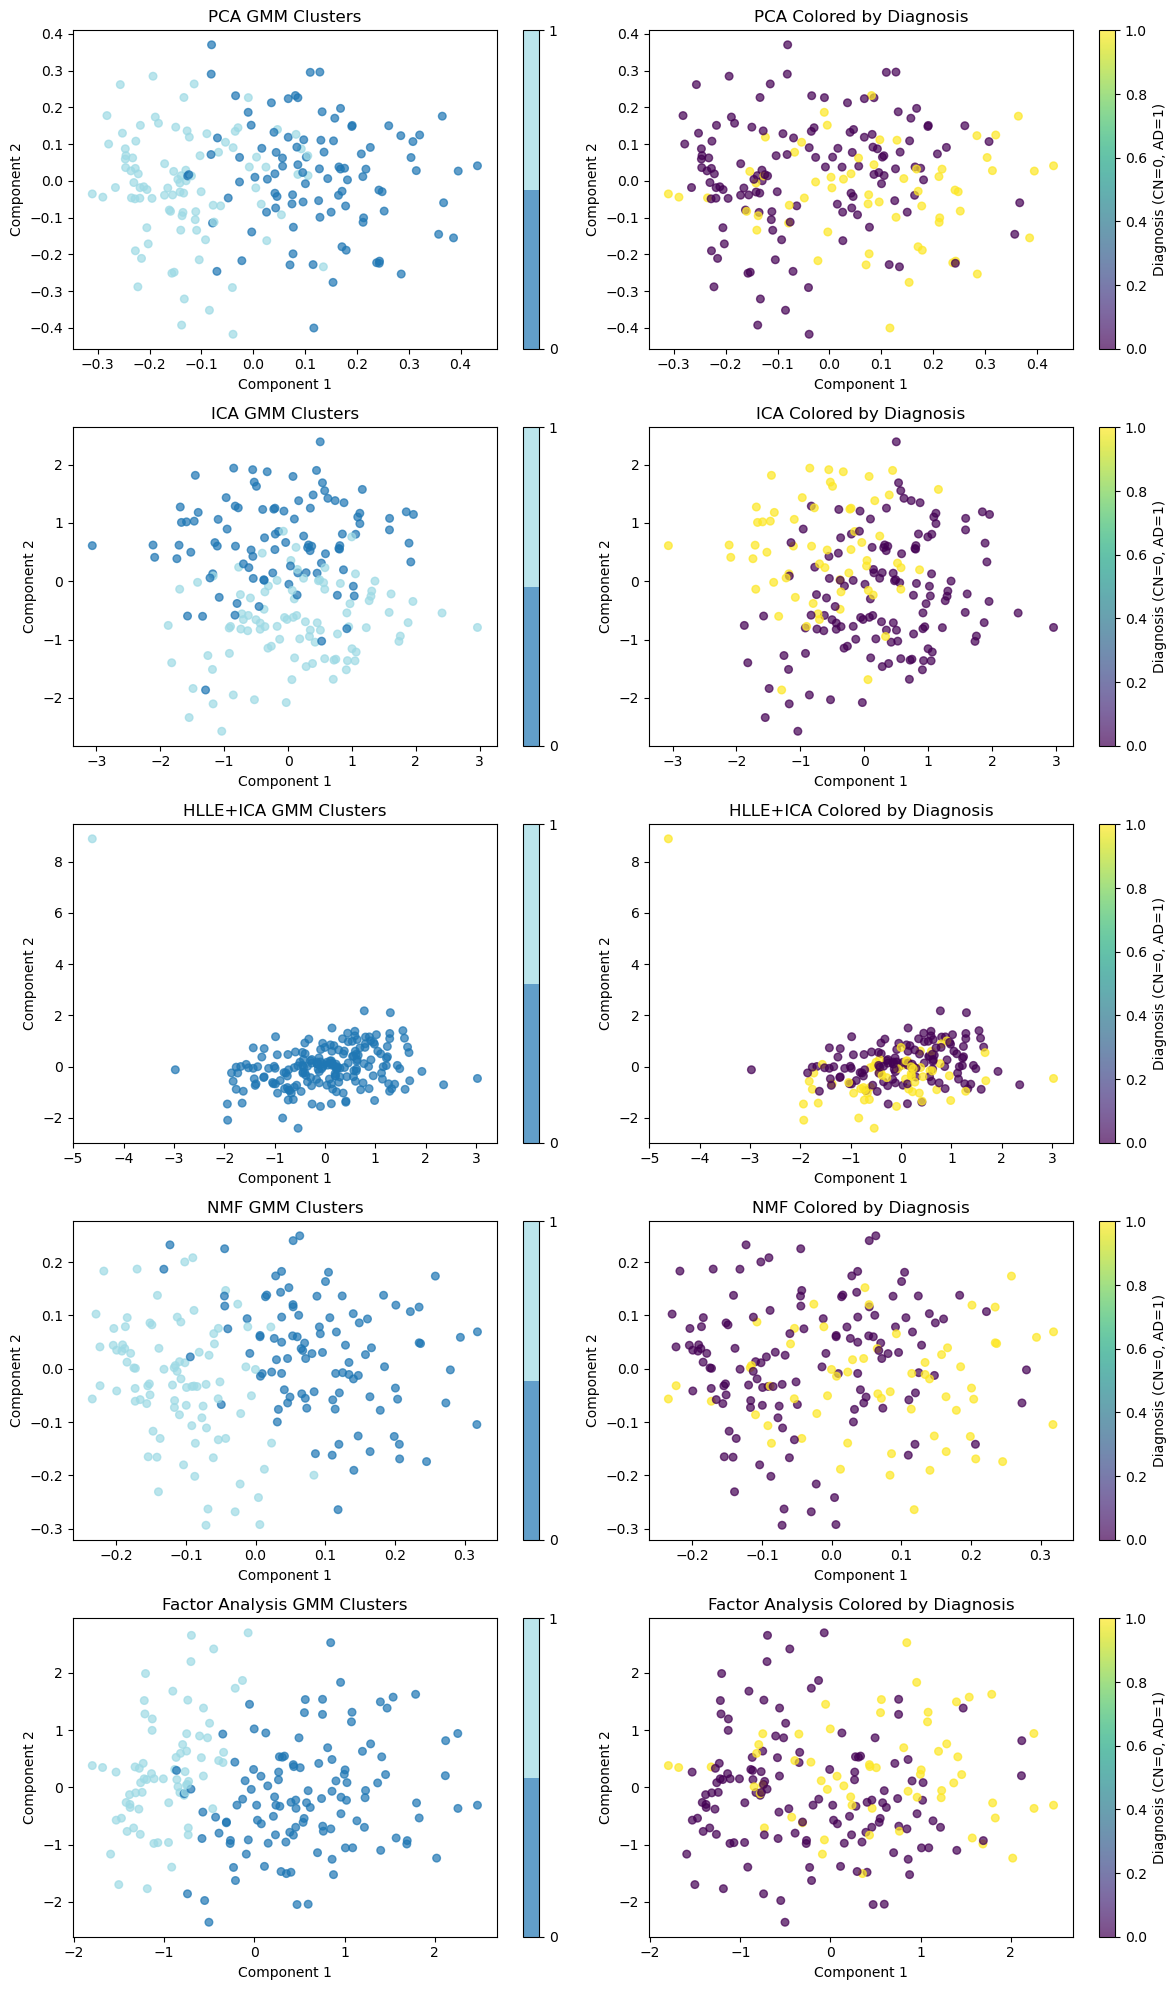

In [178]:
# 14. Visualize GMM clustering results and report purity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print('\n14. Visualizing GMM clustering + purity (PCA/ICA/HLLE+ICA/NMF/FA):')

if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'clustering_results' not in globals():
    raise RuntimeError('clustering_results not found. Run the GMM clustering cell first.')
if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found. Run the data loading cell first.')

def _cluster_purity(labels, targets):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets)
    labels = labels[mask]
    targets = targets[mask]
    if labels.size == 0:
        return float('nan'), {}
    purity_sum = 0
    details = {}
    for label in sorted(set(labels)):
        cluster_mask = labels == label
        cluster_targets = targets[cluster_mask]
        if cluster_targets.size == 0:
            continue
        values, counts = np.unique(cluster_targets, return_counts=True)
        major = counts.max()
        purity = major / counts.sum()
        purity_sum += major
        details[int(label)] = {
            'size': int(counts.sum()),
            'purity': float(purity),
            'breakdown': {int(v): int(c) for v, c in zip(values, counts)},
        }
    overall = purity_sum / labels.size if labels.size > 0 else float('nan')
    return overall, details

methods = ['PCA', 'ICA', 'HLLE+ICA', 'NMF', 'FA']
display_names = {
    'PCA': 'PCA',
    'ICA': 'ICA',
    'HLLE+ICA': 'HLLE+ICA',
    'NMF': 'NMF',
    'FA': 'Factor Analysis',
}
method_keys = []
for method in methods:
    key = f'GMM_Best_{method}'
    if key in clustering_results and results.get(method) is not None:
        method_keys.append((method, key))

if not method_keys:
    print('No GMM results found for PCA/ICA/HLLE+ICA/NMF/FA.')
else:
    n_rows = len(method_keys)
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    for row_idx, (method, key) in enumerate(method_keys):
        embedding = results.get(method)
        labels = np.asarray(clustering_results[key])

        if embedding.shape[1] == 1:
            X_vis = np.column_stack([embedding[:, 0], np.zeros(len(embedding))])
        elif embedding.shape[1] == 2:
            X_vis = embedding
        else:
            X_vis = PCA(n_components=2).fit_transform(embedding)

        unique_labels = sorted(set(labels))
        label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
        color_ids = np.vectorize(label_to_index.get)(labels)
        cmap = plt.get_cmap('tab20', max(len(unique_labels), 1))
        method_name = display_names.get(method, method)

        ax_clusters = axes[row_idx, 0]
        sc = ax_clusters.scatter(X_vis[:, 0], X_vis[:, 1], c=color_ids, cmap=cmap, s=30, alpha=0.7)
        ax_clusters.set_title(f'{method_name} GMM Clusters')
        ax_clusters.set_xlabel('Component 1')
        ax_clusters.set_ylabel('Component 2')
        cbar = plt.colorbar(sc, ax=ax_clusters, ticks=range(len(unique_labels)))
        cbar.ax.set_yticklabels(unique_labels)

        ax_diag = axes[row_idx, 1]
        sc2 = ax_diag.scatter(X_vis[:, 0], X_vis[:, 1], c=diagnosis, cmap='viridis', s=30, alpha=0.7)
        ax_diag.set_title(f'{method_name} Colored by Diagnosis')
        ax_diag.set_xlabel('Component 1')
        ax_diag.set_ylabel('Component 2')
        plt.colorbar(sc2, ax=ax_diag, label='Diagnosis (CN=0, AD=1)')

        purity, details = _cluster_purity(labels, diagnosis)
        print(f'\n{method_name} purity: {purity:.3f}')
        for cid in sorted(details):
            info = details[cid]
            print(f"  cluster {cid}: size={info['size']}, purity={info['purity']:.3f}, breakdown={info['breakdown']}")

    plt.tight_layout()
    plt.show()


In [148]:
# 16. High-confidence GMM filtering (purity vs coverage)
import numpy as np
from sklearn.preprocessing import StandardScaler

print('\n16. High-confidence GMM filtering (purity vs coverage):')

if 'gmm_models_by_method' not in globals():
    raise RuntimeError('gmm_models_by_method not found. Run the GMM clustering cell first.')
if 'results' not in globals():
    raise RuntimeError('results not found. Run the embedding cells first.')
if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found. Run the label-loading cell first.')

def _cluster_purity(labels, targets):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets) & (targets >= 0)
    labels = labels[mask]
    targets = targets[mask]
    if labels.size == 0:
        return float('nan'), {}
    purity_sum = 0
    details = {}
    for label in sorted(set(labels)):
        cluster_mask = labels == label
        cluster_targets = targets[cluster_mask]
        if cluster_targets.size == 0:
            continue
        values, counts = np.unique(cluster_targets, return_counts=True)
        major = counts.max()
        purity = major / counts.sum()
        purity_sum += major
        details[int(label)] = {
            'size': int(counts.sum()),
            'purity': float(purity),
            'breakdown': {int(v): int(c) for v, c in zip(values, counts)},
        }
    overall = purity_sum / labels.size if labels.size > 0 else float('nan')
    return overall, details

threshold = 0.95  # adjust to trade purity vs coverage

for name, model in gmm_models_by_method.items():
    if model is None:
        print(f'{name}: model missing, skipping.')
        continue
    embedding = results.get(name)
    if embedding is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    scaler = StandardScaler()
    X_emb = scaler.fit_transform(embedding)

    probs = model.predict_proba(X_emb)
    conf = probs.max(axis=1)
    keep = conf >= threshold

    if keep.sum() == 0:
        print(f'{name}: no samples above threshold={threshold:.2f}.')
        continue

    labels = model.predict(X_emb)
    purity, details = _cluster_purity(labels[keep], np.asarray(diagnosis)[keep])
    coverage = float(keep.mean())

    print(f'\n{name}: purity={purity:.3f}, coverage={coverage:.3f} (threshold={threshold:.2f})')
    for cid in sorted(details):
        info = details[cid]
        breakdown = info.get('breakdown', {})
        cn = int(breakdown.get(0, 0))
        ad = int(breakdown.get(1, 0))
        print(f"  cluster {cid}: CN={cn}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")



16. High-confidence GMM filtering (purity vs coverage):

PCA: purity=0.792, coverage=0.628 (threshold=0.95)
  cluster 0: CN=20, AD=36, size=56, purity=0.643
  cluster 1: CN=59, AD=5, size=64, purity=0.922

ICA: purity=0.792, coverage=0.628 (threshold=0.95)
  cluster 0: CN=20, AD=36, size=56, purity=0.643
  cluster 1: CN=59, AD=5, size=64, purity=0.922

HLLE+ICA: purity=0.702, coverage=1.000 (threshold=0.95)
  cluster 0: CN=0, AD=4, size=4, purity=1.000
  cluster 1: CN=130, AD=57, size=187, purity=0.695

NMF: purity=0.587, coverage=0.634 (threshold=0.95)
  cluster 0: CN=66, AD=50, size=116, purity=0.569
  cluster 1: CN=5, AD=0, size=5, purity=1.000

FA: purity=0.732, coverage=0.429 (threshold=0.95)
  cluster 0: CN=28, AD=4, size=32, purity=0.875
  cluster 1: CN=18, AD=32, size=50, purity=0.640


In [179]:
# 17. GMM on full latent codes (X) + purity (with confidence filtering)
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('\n17. GMM on full latent codes (X) + purity (with confidence filtering):')

if 'X' not in globals():
    raise RuntimeError('X not found. Run the latent loading cell first.')
if 'diagnosis' not in globals():
    raise RuntimeError('diagnosis not found. Run the label-loading cell first.')

def _cluster_purity(labels, targets):
    labels = np.asarray(labels)
    targets = np.asarray(targets)
    mask = np.isfinite(labels) & np.isfinite(targets) & (targets >= 0)
    labels = labels[mask]
    targets = targets[mask]
    if labels.size == 0:
        return float('nan'), {}
    purity_sum = 0
    details = {}
    for label in sorted(set(labels)):
        cluster_mask = labels == label
        cluster_targets = targets[cluster_mask]
        if cluster_targets.size == 0:
            continue
        values, counts = np.unique(cluster_targets, return_counts=True)
        major = counts.max()
        purity = major / counts.sum()
        purity_sum += major
        details[int(label)] = {
            'size': int(counts.sum()),
            'purity': float(purity),
            'breakdown': {int(v): int(c) for v, c in zip(values, counts)},
        }
    overall = purity_sum / labels.size if labels.size > 0 else float('nan')
    return overall, details

k_fixed = 2
threshold = 0.90  # adjust to trade purity vs coverage

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gmm_latent = GaussianMixture(n_components=k_fixed, random_state=42)
latent_labels = gmm_latent.fit_predict(X_scaled)
latent_probs = gmm_latent.predict_proba(X_scaled)

sil_score = silhouette_score(X_scaled, latent_labels) if len(set(latent_labels)) > 1 else -1.0
aic_score = gmm_latent.aic(X_scaled)
bic_score = gmm_latent.bic(X_scaled)

purity_all, details_all = _cluster_purity(latent_labels, np.asarray(diagnosis))

print(f'K={k_fixed}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}')
print(f'Purity (all): {purity_all:.3f}')
for cid in sorted(details_all):
    info = details_all[cid]
    breakdown = info.get('breakdown', {})
    cn = int(breakdown.get(0, 0))
    ad = int(breakdown.get(1, 0))
    print(f"  cluster {cid}: CN={cn}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

conf = latent_probs.max(axis=1)
keep = conf >= threshold
if keep.sum() == 0:
    print(f'No samples above threshold={threshold:.2f}.')
else:
    purity_filt, details_filt = _cluster_purity(latent_labels[keep], np.asarray(diagnosis)[keep])
    coverage = float(keep.mean())
    print(f'\nPurity (filtered): {purity_filt:.3f}, coverage={coverage:.3f} (threshold={threshold:.2f})')
    for cid in sorted(details_filt):
        info = details_filt[cid]
        breakdown = info.get('breakdown', {})
        cn = int(breakdown.get(0, 0))
        ad = int(breakdown.get(1, 0))
        print(f"  cluster {cid}: CN={cn}, AD={ad}, size={info['size']}, purity={info['purity']:.3f}")

gmm_latent_results = {
    'model': gmm_latent,
    'labels': latent_labels,
    'probs': latent_probs,
    'silhouette': sil_score,
    'aic': aic_score,
    'bic': bic_score,
    'purity_all': purity_all,
    'details_all': details_all,
    'threshold': threshold,
}



17. GMM on full latent codes (X) + purity (with confidence filtering):
K=2: Silhouette=0.034, AIC=-159701.6, BIC=55940.4
Purity (all): 0.754
  cluster 0: CN=30, AD=44, size=74, purity=0.595
  cluster 1: CN=100, AD=17, size=117, purity=0.855

Purity (filtered): 0.754, coverage=1.000 (threshold=0.90)
  cluster 0: CN=30, AD=44, size=74, purity=0.595
  cluster 1: CN=100, AD=17, size=117, purity=0.855


CN count: 117 | OA count: 74
Missing volume IDs: 0
Missing diag: 0


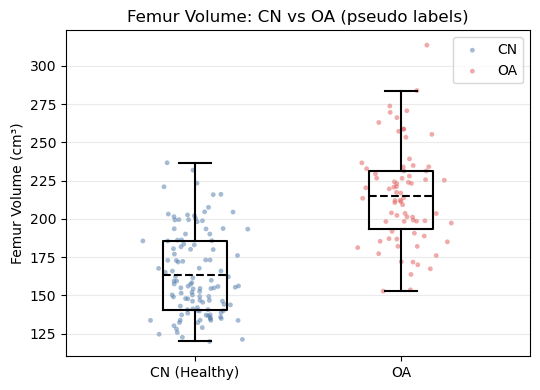

In [25]:
# --- OAI-ZIB femur volume plot (with debug + dots) ---
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# If running in notebook, ensure inline
# %matplotlib inline

if 'mesh_root' not in globals():
    raise RuntimeError('mesh_root not found.')

base_dir = os.path.dirname(mesh_root)
metrics_path = os.path.join(base_dir, 'mesh_minimal', 'mesh_metrics.csv')
metrics = pd.read_csv(metrics_path)
metrics['patient_id'] = metrics['patient_id'].astype(str)
vol_col = 'seg_volume_mm3'
volume_map = dict(zip(metrics['patient_id'], metrics[vol_col]))

# Pseudo labels
pseudo_path = os.path.join(mesh_root, 'pseudo_label_gmm.pt')
pseudo_map = torch.load(pseudo_path, map_location='cpu')
if not isinstance(pseudo_map, dict):
    raise RuntimeError('pseudo_label_gmm.pt is not a dict')

def _norm_key(k):
    base = os.path.splitext(os.path.basename(str(k)))[0]
    if base.endswith('_femur'):
        base = base[:-6]
    return base

def _to_int(x):
    try:
        return int(x.item()) if hasattr(x, 'item') else int(x)
    except Exception:
        return None

cn_vol, oa_vol = [], []
missing_vol = 0
missing_diag = 0

for k, plab in pseudo_map.items():
    pid = _norm_key(k)
    if pid not in volume_map:
        missing_vol += 1
        continue
    diag = _to_int(plab[0]) if plab is not None and len(plab) > 0 else None
    if diag not in (0, 1):
        missing_diag += 1
        continue
    vol = volume_map[pid]
    if not np.isfinite(vol):
        continue
    (cn_vol if diag == 0 else oa_vol).append(vol)

cn_vol = np.array(cn_vol, dtype=float)
oa_vol = np.array(oa_vol, dtype=float)

print(f'CN count: {len(cn_vol)} | OA count: {len(oa_vol)}')
print(f'Missing volume IDs: {missing_vol}')
print(f'Missing diag: {missing_diag}')

# Dots + box
plt.figure(figsize=(5.5, 4.0))
positions = [1.0, 1.8]
jitter = 0.08

if cn_vol.size:
    plt.scatter(
        np.random.normal(positions[0], jitter, size=cn_vol.size),
        cn_vol / 1000.0,
        s=12, alpha=0.5, color='#4C78A8', edgecolors='none', label='CN'
    )
if oa_vol.size:
    plt.scatter(
        np.random.normal(positions[1], jitter, size=oa_vol.size),
        oa_vol / 1000.0,
        s=12, alpha=0.5, color='#E45756', edgecolors='none', label='OA'
    )

plt.boxplot(
    [cn_vol/1000.0, oa_vol/1000.0],
    positions=positions,
    widths=0.25,
    showfliers=False,
    showmeans=True,
    meanline=True,
    boxprops={'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5},
    capprops={'linewidth': 1.5},
    medianprops={'color': 'none', 'linewidth': 0},
    meanprops={'color': 'black', 'linewidth': 1.5},
)

plt.xticks(positions, ['CN (Healthy)', 'OA'])
plt.ylabel('Femur Volume (cm³)')
plt.title('Femur Volume: CN vs OA (pseudo labels)')
plt.grid(True, axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
# 18. KNN prediction from most-correlated component (PCA / ICA / HLLE+ICA)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score

def _best_corr_component(embedding, target, mask):
    embedding = np.asarray(embedding)
    target = np.asarray(target)
    if embedding.ndim != 2:
        return None
    if mask is None:
        mask = np.ones(len(embedding), dtype=bool)
    mask = mask & np.all(np.isfinite(embedding), axis=1) & np.isfinite(target)
    if not np.any(mask):
        return None
    corrs = []
    for i in range(embedding.shape[1]):
        x = embedding[mask, i]
        y = target[mask]
        if np.std(x) == 0 or np.std(y) == 0:
            corrs.append(np.nan)
        else:
            corrs.append(np.corrcoef(x, y)[0, 1])
    corrs = np.array(corrs, dtype=float)
    if np.all(~np.isfinite(corrs)):
        return None
    best_idx = int(np.nanargmax(np.abs(corrs)))
    return best_idx, corrs

def _knn_classify_1d(x, y, k=5):
    X = x.reshape(-1, 1)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    k_eff = max(1, min(k, len(X_train_s)))
    clf = KNeighborsClassifier(n_neighbors=k_eff)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_val_s)
    acc = accuracy_score(y_val, y_pred)
    auc = float('nan')
    if len(np.unique(y)) > 1 and hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_val_s)[:, 1]
        auc = roc_auc_score(y_val, y_proba)
    return acc, auc, len(y_train), len(y_val)

def _knn_regress_1d(x, y, k=5):
    X = x.reshape(-1, 1)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    k_eff = max(1, min(k, len(X_train_s)))
    reg = KNeighborsRegressor(n_neighbors=k_eff)
    reg.fit(X_train_s, y_train)
    y_pred = reg.predict(X_val_s)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    r2 = r2_score(y_val, y_pred)
    return mae, rmse, r2, len(y_train), len(y_val)

embedding_sources = {
    'PCA': results.get('PCA') if 'results' in globals() else None,
    'ICA': results.get('ICA') if 'results' in globals() else None,
    'HLLE+ICA': results.get('HLLE+ICA') if 'results' in globals() else None,
}

print('\nKNN prediction using most-correlated component (1D):')

for name, emb in embedding_sources.items():
    if emb is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    emb = np.asarray(emb)

    # Disease prediction (diagnosis == 1)
    if 'diagnosis' not in globals():
        print(f'{name}: diagnosis missing, skipping disease prediction.')
    else:
        mask = diagnosis >= 0
        res = _best_corr_component(emb, diagnosis, mask)
        if res is None:
            print(f'{name}: cannot compute disease correlation.')
        else:
            best_idx, corrs = res
            best_corr = corrs[best_idx]
            y = (diagnosis[mask] == 1).astype(int)
            x = emb[mask, best_idx]
            if len(np.unique(y)) < 2:
                print(f'{name}: only one class in diagnosis, skipping KNN.')
            else:
                acc, auc, ntr, nva = _knn_classify_1d(x, y, k=5)
                print(f'{name} disease: comp {best_idx + 1} corr={best_corr:.4f}, acc={acc:.3f}, auc={auc:.3f} (n_train={ntr}, n_val={nva})')

    # Age prediction
    if 'age' not in globals():
        print(f'{name}: age missing, skipping age prediction.')
    else:
        mask = np.isfinite(age)
        res = _best_corr_component(emb, age, mask)
        if res is None:
            print(f'{name}: cannot compute age correlation.')
        else:
            best_idx, corrs = res
            best_corr = corrs[best_idx]
            x = emb[mask, best_idx]
            y = age[mask]
            if len(y) < 5:
                print(f'{name}: not enough age samples, skipping KNN.')
            else:
                mae, rmse, r2, ntr, nva = _knn_regress_1d(x, y, k=5)
                print(f'{name} age: comp {best_idx + 1} corr={best_corr:.4f}, MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f} (n_train={ntr}, n_val={nva})')

                y_min = float(np.nanmin(y))
                y_max = float(np.nanmax(y))
                y_range = y_max - y_min
                if y_range <= 0:
                    print(f'{name} age norm: range=0, skipping normalized age.')
                else:
                    y_norm = (y - y_min) / y_range
                    mae_n, rmse_n, r2_n, ntr, nva = _knn_regress_1d(x, y_norm, k=5)
                    print(f'{name} age norm: comp {best_idx + 1} corr={best_corr:.4f}, MAE={mae_n:.3f}, RMSE={rmse_n:.3f}, R2={r2_n:.3f} (n_train={ntr}, n_val={nva})')



KNN prediction using most-correlated component (1D):
PCA disease: comp 1 corr=-0.5795, acc=0.693, auc=0.752 (n_train=556, n_val=140)
PCA age: comp 1 corr=-0.2202, MAE=4.843, RMSE=5.999, R2=-0.132 (n_train=556, n_val=140)
PCA age norm: comp 1 corr=-0.2202, MAE=0.142, RMSE=0.176, R2=-0.132 (n_train=556, n_val=140)
ICA disease: comp 2 corr=0.5640, acc=0.621, auc=0.716 (n_train=556, n_val=140)
ICA age: comp 2 corr=0.2051, MAE=4.500, RMSE=5.567, R2=0.025 (n_train=556, n_val=140)
ICA age norm: comp 2 corr=0.2051, MAE=0.132, RMSE=0.164, R2=0.025 (n_train=556, n_val=140)
HLLE+ICA disease: comp 3 corr=0.6192, acc=0.729, auc=0.804 (n_train=556, n_val=140)
HLLE+ICA age: comp 3 corr=0.1822, MAE=4.520, RMSE=5.728, R2=-0.032 (n_train=556, n_val=140)
HLLE+ICA age norm: comp 3 corr=0.1822, MAE=0.133, RMSE=0.168, R2=-0.032 (n_train=556, n_val=140)


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

In [18]:
# 19. SAP summary for disease and age (PCA / ICA / HLLE+ICA)
import numpy as np
from sdf_utils import sap as sap_metric

if '_mask_codes_factors' not in globals():
    def _mask_codes_factors(codes, factors, mask=None):
        codes = np.asarray(codes)
        factors = np.asarray(factors)
        if factors.ndim == 1:
            factors = factors.reshape(-1, 1)
        if codes.shape[0] != factors.shape[0]:
            print(f'  Skipping: codes/factors row mismatch ({codes.shape[0]} vs {factors.shape[0]})')
            return None, None
        if mask is not None:
            codes = codes[mask]
            factors = factors[mask]
        finite_mask = np.isfinite(factors).all(axis=1) & np.isfinite(codes).all(axis=1)
        codes = codes[finite_mask]
        factors = factors[finite_mask]
        if codes.shape[0] < 4:
            print('  Skipping: not enough valid samples after filtering.')
            return None, None
        return codes, factors

def _sap_disease_score(codes, diagnosis, nb_bins=10):
    mask = diagnosis >= 0
    codes_m, factors_m = _mask_codes_factors(codes, diagnosis, mask=mask)
    if codes_m is None:
        return None
    return sap_metric.sap(
        factors_m,
        codes_m,
        continuous_factors=False,
        nb_bins=nb_bins,
        regression=False,
    )

def _sap_age_score(codes, age):
    mask = np.isfinite(age)
    codes_m, factors_m = _mask_codes_factors(codes, age, mask=mask)
    if codes_m is None:
        return None
    return sap_metric.sap(
        factors_m,
        codes_m,
        continuous_factors=True,
        regression=True,
    )

embedding_sources = {
    'PCA': results.get('PCA') if 'results' in globals() else None,
    'ICA': results.get('ICA') if 'results' in globals() else None,
    'HLLE+ICA': results.get('HLLE+ICA') if 'results' in globals() else None,
}

print('\nSAP summary (disease + age):')
for name, emb in embedding_sources.items():
    if emb is None:
        print(f'{name}: embedding missing, skipping.')
        continue
    if 'diagnosis' in globals():
        sap_d = _sap_disease_score(emb, diagnosis)
    else:
        sap_d = None
    if 'age' in globals():
        sap_a = _sap_age_score(emb, age)
    else:
        sap_a = None
    d_str = f'{sap_d:.6f}' if sap_d is not None else 'NA'
    a_str = f'{sap_a:.6f}' if sap_a is not None else 'NA'
    print(f'{name}: disease SAP={d_str} | age SAP={a_str}')



SAP summary (disease + age):
PCA: disease SAP=0.125000 | age SAP=0.038998
ICA: disease SAP=0.102011 | age SAP=0.029245
HLLE+ICA: disease SAP=0.166667 | age SAP=0.018289


In [49]:
# 20. KMeans age prediction using latent positions 0 and 1 (pseudo_label_with_age)
import os
import json
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import deep_sdf.workspace as ws

experiment_dir_age = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_only_age_dip_vae'
checkpoint_age = 'latest'

# Load latent vectors
latent_vectors_age = ws.load_latent_vectors(experiment_dir_age, checkpoint_age)
X_age_latent = latent_vectors_age.cpu().numpy()
print(f'Loaded latents from {experiment_dir_age}: {X_age_latent.shape}')

# Load labels + age
with open(os.path.join(experiment_dir_age, 'specs.json'), 'r') as f:
    specs_age = json.load(f)

mesh_root_age = specs_age.get('DataSourceMesh', specs_age['DataSource'])
train_split_file_age = specs_age.get('TrainSplit')
test_split_file_age = specs_age.get('TestSplit')
labels_path_age = os.path.join(mesh_root_age, 'labels.pt')

def _load_split_age(path):
    if not path:
        return []
    with open(path, 'r') as f:
        return json.load(f)

train_split_age = _load_split_age(train_split_file_age)
test_split_age = _load_split_age(test_split_file_age)

split_list_age = []
seen_age = set()
for name in train_split_age + test_split_age:
    if name not in seen_age:
        split_list_age.append(name)
        seen_age.add(name)

valid_filenames_age = split_list_age
if X_age_latent.shape[0] != len(valid_filenames_age):
    if len(train_split_age) == X_age_latent.shape[0]:
        print('Latent count matches train split; using train split only.')
        valid_filenames_age = train_split_age
    else:
        print('Warning: latent count does not match split sizes.')

age_vals = []
if os.path.exists(labels_path_age):
    labels_raw = torch.load(labels_path_age, map_location='cpu')
    label_map = labels_raw
    if not isinstance(labels_raw, dict):
        if hasattr(labels_raw, '__len__') and len(labels_raw) == len(valid_filenames_age):
            label_map = {}
            for idx, filename in enumerate(valid_filenames_age):
                base_name = os.path.splitext(os.path.basename(filename))[0]
                label_map[base_name] = labels_raw[idx]
        else:
            print('Warning: labels are not a dict and length does not match filenames; skipping label lookup.')
            label_map = {}

    for filename in valid_filenames_age:
        base_name = os.path.splitext(os.path.basename(filename))[0]
        if base_name in label_map:
            label = label_map[base_name]
            age_vals.append(float(label[1].item()))
        else:
            age_vals.append(float('nan'))
else:
    print(f'labels.pt not found at {labels_path_age}')
    age_vals = [float('nan')] * len(valid_filenames_age)

age_vals = np.array(age_vals, dtype=float)

def _kmeans_age_predict(x, y, k=5):
    X_train, X_val, y_train, y_val = train_test_split(
        x, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)

    k_eff = max(1, min(k, len(X_train_s)))
    km = KMeans(n_clusters=k_eff, random_state=42, n_init=10)
    km.fit(X_train_s)

    train_labels = km.labels_
    cluster_means = {}
    for c in range(k_eff):
        c_mask = train_labels == c
        if np.any(c_mask):
            cluster_means[c] = float(np.mean(y_train[c_mask]))
        else:
            cluster_means[c] = float('nan')

    val_labels = km.predict(X_val_s)
    y_pred = np.array([cluster_means.get(c, float('nan')) for c in val_labels], dtype=float)
    if np.any(~np.isfinite(y_pred)):
        global_mean = float(np.mean(y_train))
        y_pred = np.where(np.isfinite(y_pred), y_pred, global_mean)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    r2 = r2_score(y_val, y_pred)
    return mae, rmse, r2, len(y_train), len(y_val)

print('\nKMeans age prediction (1D latent):')
mask = np.isfinite(age_vals)
if not np.any(mask):
    print('No valid age values found.')
else:
    # Normalize age to [0, 1] for comparison
    age_min = float(np.nanmin(age_vals[mask]))
    age_max = float(np.nanmax(age_vals[mask]))
    age_range = age_max - age_min
    if age_range <= 0:
        age_norm = None
        print('Age range is zero; normalized age not available.')
    else:
        age_norm = (age_vals - age_min) / age_range

    for dim in [0, 1]:
        if X_age_latent.shape[1] <= dim:
            print(f'Latent dim {dim}: not available (latent dim = {X_age_latent.shape[1]})')
            continue
        x = X_age_latent[mask, dim].reshape(-1, 1)
        y_raw = age_vals[mask]
        if len(y_raw) < 5:
            print(f'Latent dim {dim}: not enough samples for KMeans.')
            continue
        mae, rmse, r2, ntr, nva = _kmeans_age_predict(x, y_raw, k=5)
        print(f'Latent dim {dim} (raw age): MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f} (n_train={ntr}, n_val={nva})')

        if age_norm is not None:
            y_norm = age_norm[mask]
            mae_n, rmse_n, r2_n, ntr, nva = _kmeans_age_predict(x, y_norm, k=5)
            print(f'Latent dim {dim} (norm age 0-1): MAE={mae_n:.3f}, RMSE={rmse_n:.3f}, R2={r2_n:.3f} (n_train={ntr}, n_val={nva})')


Loaded latents from examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_only_age_dip_vae: (696, 4)
Latent count matches train split; using train split only.

KMeans age prediction (1D latent):
Latent dim 0 (raw age): MAE=4.480, RMSE=5.687, R2=-0.017 (n_train=556, n_val=140)
Latent dim 0 (norm age 0-1): MAE=0.132, RMSE=0.167, R2=-0.017 (n_train=556, n_val=140)
Latent dim 1 (raw age): MAE=1.487, RMSE=2.168, R2=0.852 (n_train=556, n_val=140)
Latent dim 1 (norm age 0-1): MAE=0.044, RMSE=0.064, R2=0.852 (n_train=556, n_val=140)


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

In [62]:
# 21. KMeans disease prediction using latent position 0 (pseudo_label_with_age)
import os
import json
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import deep_sdf.workspace as ws

experiment_dir_age = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_pseudo_label_with_age'
checkpoint_age = 'latest'

latent_vectors_age = ws.load_latent_vectors(experiment_dir_age, checkpoint_age)
X_age_latent = latent_vectors_age.cpu().numpy()

with open(os.path.join(experiment_dir_age, 'specs.json'), 'r') as f:
    specs_age = json.load(f)
mesh_root_age = specs_age.get('DataSourceMesh', specs_age['DataSource'])
train_split_file_age = specs_age.get('TrainSplit')
test_split_file_age = specs_age.get('TestSplit')
labels_path_age = os.path.join(mesh_root_age, 'labels.pt')

def _load_split_age(path):
    if not path:
        return []
    with open(path, 'r') as f:
        return json.load(f)

train_split_age = _load_split_age(train_split_file_age)
test_split_age = _load_split_age(test_split_file_age)

split_list_age = []
seen_age = set()
for name in train_split_age + test_split_age:
    if name not in seen_age:
        split_list_age.append(name)
        seen_age.add(name)

valid_filenames_age = split_list_age
if X_age_latent.shape[0] != len(valid_filenames_age):
    if len(train_split_age) == X_age_latent.shape[0]:
        valid_filenames_age = train_split_age
    else:
        print('Warning: latent count does not match split sizes.')

diag_vals = []
age_vals = []
if os.path.exists(labels_path_age):
    labels_raw = torch.load(labels_path_age, map_location='cpu')
    label_map = labels_raw
    if not isinstance(labels_raw, dict):
        if hasattr(labels_raw, '__len__') and len(labels_raw) == len(valid_filenames_age):
            label_map = {}
            for idx, filename in enumerate(valid_filenames_age):
                base_name = os.path.splitext(os.path.basename(filename))[0]
                label_map[base_name] = labels_raw[idx]
        else:
            print('Warning: labels are not a dict and length does not match filenames; skipping label lookup.')
            label_map = {}

    for filename in valid_filenames_age:
        base_name = os.path.splitext(os.path.basename(filename))[0]
        if base_name in label_map:
            label = label_map[base_name]
            diag_vals.append(int(label[0].item()))
            age_vals.append(float(label[1].item()))
        else:
            diag_vals.append(-1)
            age_vals.append(float('nan'))
else:
    print(f'labels.pt not found at {labels_path_age}')
    diag_vals = [-1] * len(valid_filenames_age)
    age_vals = [float('nan')] * len(valid_filenames_age)

diag_vals = np.array(diag_vals, dtype=int)
age_vals = np.array(age_vals, dtype=float)

def _corr_safe(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if not np.any(mask):
        return float('nan')
    x = x[mask]
    y = y[mask]
    if x.size < 2 or np.std(x) == 0 or np.std(y) == 0:
        return float('nan')
    return float(np.corrcoef(x, y)[0, 1])

def _kmeans_disease_predict(x, y, k=2):
    X_train, X_val, y_train, y_val = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)

    k_eff = max(2, min(k, len(X_train_s)))
    km = KMeans(n_clusters=k_eff, random_state=42, n_init=10)
    km.fit(X_train_s)

    train_labels = km.labels_
    cluster_majority = {}
    for c in range(k_eff):
        c_mask = train_labels == c
        if np.any(c_mask):
            vals, counts = np.unique(y_train[c_mask], return_counts=True)
            cluster_majority[c] = int(vals[np.argmax(counts)])
        else:
            cluster_majority[c] = int(np.bincount(y_train).argmax())

    val_labels = km.predict(X_val_s)
    y_pred = np.array([cluster_majority.get(c, 0) for c in val_labels], dtype=int)

    acc = accuracy_score(y_val, y_pred)
    auc = float('nan')
    if len(np.unique(y_val)) > 1:
        auc = roc_auc_score(y_val, y_pred)
    return acc, auc, len(y_train), len(y_val)

print('\nCorrelation by latent dimension (first 4 dims):')
diag_mask = diag_vals >= 0
age_mask = np.isfinite(age_vals)

age_norm = None
age_real = None
if np.any(age_mask):
    age_real = age_vals[age_mask]
    age_min = float(np.nanmin(age_real))
    age_max = float(np.nanmax(age_real))
    age_range = age_max - age_min
    if age_range > 0:
        age_norm = (age_real - age_min) / age_range

max_dims = min(4, X_age_latent.shape[1])
for dim in range(max_dims):
    x_all = X_age_latent[:, dim]
    if np.any(diag_mask):
        y_d = (diag_vals[diag_mask] == 1).astype(int)
        corr_d = _corr_safe(x_all[diag_mask], y_d)
    else:
        corr_d = float('nan')

    if np.any(age_mask):
        corr_a = _corr_safe(x_all[age_mask], age_real)
    else:
        corr_a = float('nan')

    print(f'dim {dim}: corr_disease={corr_d:.4f}, corr_age={corr_a:.4f}')

    if age_norm is not None:
        corr_an = _corr_safe(x_all[age_mask], age_norm)
        print(f'      corr_age_norm={corr_an:.4f}')

print('\nKMeans disease prediction (latent dim 0):')
if not np.any(diag_mask):
    print('No valid diagnosis values found.')
else:
    if X_age_latent.shape[1] < 1:
        print('Latent dim 0 not available.')
    else:
        x0 = X_age_latent[diag_mask, 0].reshape(-1, 1)
        y = (diag_vals[diag_mask] == 1).astype(int)
        if len(np.unique(y)) < 2:
            print('Only one class in diagnosis; skipping.')
        else:
            acc, auc, ntr, nva = _kmeans_disease_predict(x0, y, k=2)
            print(f'Latent dim 0: acc={acc:.3f}, auc={auc:.3f} (n_train={ntr}, n_val={nva})')



Correlation by latent dimension (first 4 dims):
dim 0: corr_disease=0.6579, corr_age=0.0393
      corr_age_norm=0.0393
dim 1: corr_disease=0.0234, corr_age=-0.9568
      corr_age_norm=-0.9568
dim 2: corr_disease=-0.0509, corr_age=-0.0223
      corr_age_norm=-0.0223
dim 3: corr_disease=-0.0522, corr_age=0.0208
      corr_age_norm=0.0208

KMeans disease prediction (latent dim 0):
Latent dim 0: acc=0.771, auc=0.769 (n_train=556, n_val=140)


In [84]:
# 25. Chamfer (train/test) for minimal_eikonal + minimal_eikonal_gmm (10 shapes each)
import os
import json
import numpy as np
import torch
import deep_sdf.workspace as ws
from deep_sdf import mesh as ds_mesh
from deep_sdf import metrics as ds_metrics

# ====== CONFIG ======
experiments = [
    'examples/ADNI_1_L_No_MCI/minimal_eikonal',
    'examples/ADNI_1_L_No_MCI/minimal_eikonal_gmm',
]
n_shapes = 100
seed = 42
grid_res = 128
max_batch = 2 ** 32
num_mesh_samples = 10000
use_cpu = False
# ====================

def _resolve_path(exp_dir, p):
    if p is None:
        return None
    if os.path.isabs(p) and os.path.exists(p):
        return p
    if os.path.exists(p):  # relative to cwd
        return p
    cand = os.path.join(exp_dir, p)
    return cand if os.path.exists(cand) else p

def _load_split(path):
    if not path or not os.path.exists(path):
        return []
    with open(path, 'r') as f:
        return json.load(f)

def _pick_checkpoint(model_dir):
    latest = os.path.join(model_dir, 'latest.pth')
    if os.path.exists(latest):
        return latest
    cands = [f for f in os.listdir(model_dir) if f.endswith('.pth') and f[:-4].isdigit()]
    if not cands:
        return None
    return os.path.join(model_dir, sorted(cands, key=lambda x: int(x[:-4]))[-1])

def _load_latents(latent_path):
    data = torch.load(latent_path, map_location='cpu')
    if isinstance(data, dict) and 'latent_codes' in data:
        lat = data['latent_codes']
        if isinstance(lat, torch.Tensor):
            return lat.cpu().numpy()
        if isinstance(lat, dict) and 'weight' in lat:
            return lat['weight'].cpu().numpy()
        # embedding state dict
        emb = torch.nn.Embedding(lat['weight'].shape[0], lat['weight'].shape[1])
        emb.load_state_dict(lat)
        return emb.weight.data.cpu().numpy()
    if isinstance(data, torch.Tensor):
        return data.cpu().numpy()
    return np.asarray(data)

def _resolve_mesh_path(mesh_root, base_name):
    candidates = [
        os.path.join(mesh_root, base_name + '.obj'),
        os.path.join(mesh_root, base_name + '.ply'),
    ]
    for c in candidates:
        if os.path.isfile(c):
            return c
    matches = [p for p in os.listdir(mesh_root) if os.path.splitext(p)[0] == base_name]
    if matches:
        return os.path.join(mesh_root, matches[0])
    return None

def _build_split_pairs(train_split, test_split, latents_len):
    # returns dict split -> list of (latent_idx, filename)
    splits = {}
    union = []
    seen = set()
    for name in train_split + test_split:
        if name not in seen:
            union.append(name)
            seen.add(name)

    if latents_len == len(train_split):
        splits['train'] = list(enumerate(train_split))
        return splits
    if latents_len == len(test_split):
        splits['test'] = list(enumerate(test_split))
        return splits
    if latents_len == len(union):
        idx_map = {name: i for i, name in enumerate(union)}
        splits['train'] = [(idx_map[n], n) for n in train_split if n in idx_map]
        splits['test'] = [(idx_map[n], n) for n in test_split if n in idx_map]
        return splits

    # no match
    return splits

device = torch.device('cuda' if torch.cuda.is_available() and not use_cpu else 'cpu')
rng = np.random.RandomState(seed)

for exp_dir in experiments:
    print(f'\n=== {exp_dir} ===')
    spec_path = os.path.join(exp_dir, 'specs.json')
    if not os.path.exists(spec_path):
        print('  specs.json missing, skipping.')
        continue
    specs = json.load(open(spec_path, 'r'))

    mesh_root = _resolve_path(exp_dir, specs.get('DataSourceMesh', specs.get('DataSource')))
    train_split_file = _resolve_path(exp_dir, specs.get('TrainSplit'))
    test_split_file = _resolve_path(exp_dir, specs.get('TestSplit'))
    train_split = _load_split(train_split_file)
    test_split = _load_split(test_split_file)

    # Load decoder
    model_dir = ws.get_model_params_dir(exp_dir)
    ckpt_path = _pick_checkpoint(model_dir)
    if ckpt_path is None:
        print('  No checkpoint found, skipping.')
        continue
    ckpt = torch.load(ckpt_path, map_location='cpu')
    state = ckpt.get('model_state_dict', ckpt)
    if all(k.startswith('module.') for k in state.keys()):
        state = {k.replace('module.', ''): v for k, v in state.items()}

    decoder = ws.build_decoder(exp_dir, specs)
    missing, unexpected = decoder.load_state_dict(state, strict=False)
    if missing or unexpected:
        print(f'  Decoder load_state_dict missing={len(missing)} unexpected={len(unexpected)}')
    decoder = decoder.to(device).eval()

    # Load latents
    latent_dir = ws.get_latent_codes_dir(exp_dir)
    latent_ckpt = os.path.join(latent_dir, 'latest.pth')
    if not os.path.exists(latent_ckpt):
        latent_ckpt = _pick_checkpoint(latent_dir)
    if latent_ckpt is None or not os.path.exists(latent_ckpt):
        print('  No latent codes found, skipping.')
        continue

    latents = _load_latents(latent_ckpt)
    n_lat = latents.shape[0]

    split_pairs = _build_split_pairs(train_split, test_split, n_lat)
    if not split_pairs:
        print(f'  Latent count ({n_lat}) does not match train/test/union; skipping.')
        continue

    def _eval_split(split_name, pairs):
        if not pairs:
            print(f'  {split_name}: no pairs available.')
            return
        n_pick = min(n_shapes, len(pairs))
        pick_idx = rng.choice(len(pairs), n_pick, replace=False)
        chamfers = []
        missing = 0
        failed = 0

        for j in pick_idx:
            lat_idx, filename = pairs[j]
            base_name = os.path.splitext(os.path.basename(filename))[0]
            gt_path = _resolve_mesh_path(mesh_root, base_name)
            if gt_path is None:
                missing += 1
                continue
            try:
                z = torch.tensor(latents[lat_idx:lat_idx+1], dtype=torch.float32).to(device)
                with torch.no_grad():
                    gen_mesh = ds_mesh.create_mesh(
                        decoder,
                        z,
                        N=grid_res,
                        max_batch=max_batch,
                        return_trimesh=True,
                    )
                if gen_mesh is None:
                    failed += 1
                    continue
                cd, _ = ds_metrics.compute_metric(
                    gt_mesh=gt_path,
                    gen_mesh=gen_mesh,
                    num_mesh_samples=num_mesh_samples,
                    metric='chamfer',
                )
                chamfers.append(cd)
                del gen_mesh
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
            except Exception as e:
                print(f'    [{split_name}] failed {base_name}: {e}')
                failed += 1
                if device.type == 'cuda':
                    torch.cuda.empty_cache()

        if chamfers:
            print(f'  {split_name}: mean Chamfer over {len(chamfers)} shapes = {float(np.mean(chamfers)):.6f}')
        else:
            print(f'  {split_name}: no Chamfer distances computed.')
        if missing or failed:
            print(f'    Missing meshes: {missing} | Failed: {failed}')

    _eval_split('train', split_pairs.get('train', []))
    _eval_split('test', split_pairs.get('test', []))



=== examples/ADNI_1_L_No_MCI/minimal_eikonal ===
  train: mean Chamfer over 100 shapes = 0.001654
  test: no pairs available.

=== examples/ADNI_1_L_No_MCI/minimal_eikonal_gmm ===
  train: mean Chamfer over 100 shapes = 0.001730
  test: no pairs available.


In [38]:
# --- Clustering on PCA / ICA / HLLE+ICA + Purity (K=2 only) ---
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

if 'results' not in globals():
    raise RuntimeError("results not found. Run PCA/ICA/HLLE+ICA cells first.")
if 'diagnosis' not in globals():
    raise RuntimeError("diagnosis not found. Run label-loading cell first.")

label_mask = diagnosis >= 0
y = diagnosis[label_mask].astype(int)

def purity_report(labels, y, name):
    labels = np.asarray(labels)
    y = np.asarray(y)
    clusters = sorted(set(labels))
    total = 0
    correct = 0
    print(f"\n{name} cluster summary:")
    for c in clusters:
        m = labels == c
        cn = int((y[m] == 0).sum())
        ad = int((y[m] == 1).sum())
        size = cn + ad
        if size == 0:
            continue
        maj = max(cn, ad)
        total += size
        correct += maj
        print(f"  Cluster {c}: size={size}, CN={cn}, AD={ad}, majority={(maj/size):.2%}")
    purity = (correct / total) if total > 0 else float('nan')
    print(f"{name} purity: {purity:.3%}")
    return purity

def cluster_and_purity(emb, emb_name):
    if emb is None:
        print(f"{emb_name}: missing, skipping.")
        return
    emb = np.asarray(emb)
    if emb.shape[0] != len(diagnosis):
        print(f"{emb_name}: size mismatch ({emb.shape[0]} vs {len(diagnosis)}), skipping.")
        return

    X_emb = emb[label_mask]
    if X_emb.shape[0] < 5:
        print(f"{emb_name}: not enough labeled samples.")
        return

    X_scaled = StandardScaler().fit_transform(X_emb)

    # KMeans (K=2)
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    print(f"\n{emb_name} | KMeans (K=2)")
    purity_report(km_labels, y, f"{emb_name} KMeans")

    # GMM (K=2)
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    print(f"{emb_name} | GMM (K=2)")
    purity_report(gmm_labels, y, f"{emb_name} GMM")

# Run for PCA / ICA / HLLE+ICA
cluster_and_purity(results.get('PCA'), 'PCA')
cluster_and_purity(results.get('ICA'), 'ICA')
cluster_and_purity(results.get('HLLE+ICA'), 'HLLE+ICA')



PCA | KMeans (K=2)

PCA KMeans cluster summary:
  Cluster 0: size=91, CN=49, AD=42, majority=53.85%
  Cluster 1: size=100, CN=81, AD=19, majority=81.00%
PCA KMeans purity: 68.063%
PCA | GMM (K=2)

PCA GMM cluster summary:
  Cluster 0: size=103, CN=54, AD=49, majority=52.43%
  Cluster 1: size=88, CN=76, AD=12, majority=86.36%
PCA GMM purity: 68.063%

ICA | KMeans (K=2)

ICA KMeans cluster summary:
  Cluster 0: size=89, CN=51, AD=38, majority=57.30%
  Cluster 1: size=102, CN=79, AD=23, majority=77.45%
ICA KMeans purity: 68.063%
ICA | GMM (K=2)

ICA GMM cluster summary:
  Cluster 0: size=97, CN=52, AD=45, majority=53.61%
  Cluster 1: size=94, CN=78, AD=16, majority=82.98%
ICA GMM purity: 68.063%

HLLE+ICA | KMeans (K=2)

HLLE+ICA KMeans cluster summary:
  Cluster 0: size=190, CN=130, AD=60, majority=68.42%
  Cluster 1: size=1, CN=0, AD=1, majority=100.00%
HLLE+ICA KMeans purity: 68.586%
HLLE+ICA | GMM (K=2)

HLLE+ICA GMM cluster summary:
  Cluster 0: size=187, CN=130, AD=57, majority=69.